# 한글 코퍼스를 활용한 Mini BERT 사전학습 프로젝트

## 프로젝트 개요
본 프로젝트는 한글 위키 코퍼스를 전처리하여 **Masked Language Modeling(MLM)**과 **Next Sentence Prediction(NSP)** 학습 데이터를 생성하고, 약 1M 파라미터 규모의 Mini BERT를 직접 구현하여 10 Epoch 동안 사전학습하는 것을 목표로 합니다.

### 핵심 수행 내용
- SentencePiece BPE 기반 8,000 vocabulary 토크나이저 구성
- BERT의 15% MLM 및 80:10:10 마스킹 규칙 구현
- 실제 다음 문장과 다른 문서의 무관한 문장을 이용한 NSP 데이터 구성
- Token·Position·Segment Embedding과 Transformer Encoder 기반 Mini BERT 구현
- MLM/NSP raw logits, 올바른 CrossEntropyLoss, Warm-up + Cosine LR Scheduler 적용
- 945,588개 파라미터 모델을 10 Epoch 학습하고 손실·정확도 시각화

### 제출 루브릭 대응
1. 한글 코퍼스로 MLM·NSP 특징이 반영된 pretraining 데이터셋 생성
2. MLM·NSP loss의 안정적인 감소 확인
3. 약 1M 규모 Mini BERT 제작, 10 Epoch 학습, 모델 및 시각화 결과 제출


# 들어가며

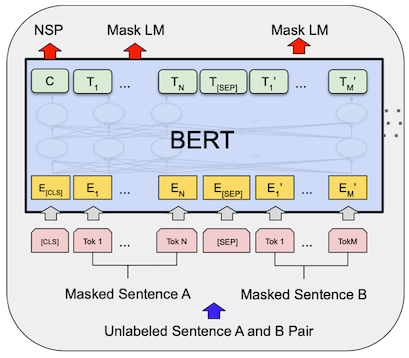

지난 시간 우리는 transformer 기반의 pretrained model의 발전사를 살펴보고, 어떻게 이 모델들이 맥락 기반의 word representation을 구성할 수 있으며 또한 Transfer learning을 통해 다양한 자연어 처리 문제를 쉽게 해결할 수 있는지 살펴보았습니다.

이런 모델들을 만들어 내기 위해서는 아주 큰 사이즈의 모델이 필요합니다. 가장 대표적인 BERT만 하더라도 정식 모델은 340M나 되는 파라미터 사이즈를 자랑합니다. 이들을 수십 GB나 되는 코퍼스를 토대로 학습시키는 것은 최고 성능의 GPU를 가지고도 수일 내지 수 주일의 시간이 걸립니다. 아마도 여러분 대부분의 학습환경에서 이를 수행하는 것은 가능한 일이 아닐 것입니다.

그래서 오늘은 일반적인 10M 정도의 작은 파라미터 사이즈의 BERT 모델을 만들어, 수백 MB 수준의 코퍼스 기반으로 pretrain 을 진행해 보도록 하겠습니다. 하지만 진행되는 과정은 정식 BERT와 동일할 테니 이를 토대로 pretrained model이 어떻게 만들어지는지를 경험해 보도록 합시다. 모델을 만들고 학습시키는 것 이상으로 코퍼스 데이터를 가공해서 학습시켜야 할 task에 적합한 형태의 데이터셋으로 만들어가는 것이 큰 비중을 차지한다는 것을 알게 될 것입니다.

오늘의 작업을 위해 다음과 같이 작업환경을 마련해 주세요. 학습에 사용할 코퍼스 데이터를 아래에 첨부해 두었습니다.

**[아이스브레이킹] NLP 모델들은 세서미 스트리트(Sesame street) 등장인물들의 이름을 따서 지었는데요, 여러분들만의 모델 이름은 뭐가 좋을까요?** \
A. [ 답변을 적어볼까요! ] \

\

<details>
<summary>💡예시답안 확인하기💡</summary>

A. 주요 인물 이름은 거의 다 쓰였어요😭 얼른 서둘러야겠어요! 여러분들의 힘을 보여주세요!

</details>

[kowiki.txt.zip](https://d3s0tskafalll9.cloudfront.net/media/documents/kowiki.txt.zip)

## 데이터 다운로드
---

```
$ mkdir -p ~/aiffel/bert_pretrain/data
$ mkdir -p ~/aiffel/bert_pretrain/models
$ wget https://aiffelstaticprd.blob.core.windows.net/media/documents/kowiki.txt.zip
$ mv kowiki.txt.zip ~/aiffel/bert_pretrain/data
$ cd ~/aiffel/bert_pretrain/data && unzip kowiki.txt.zip
```

혹시 이번 실습에서 필요한 아래 라이브러리가 없다면 미리 설치해 주세요.


```
$ pip install sentencepiece
$ pip install tqdm
$ conda install -c conda-forge ipywidgets
$ jupyter nbextension enable --py widgetsnbextension
```

In [1]:
!mkdir data
!mkdir models

In [2]:
!wget https://d3s0tskafalll9.cloudfront.net/media/documents/kowiki.txt.zip

--2026-07-18 04:29:26--  https://d3s0tskafalll9.cloudfront.net/media/documents/kowiki.txt.zip
Resolving d3s0tskafalll9.cloudfront.net (d3s0tskafalll9.cloudfront.net)... 3.165.160.93, 3.165.160.23, 3.165.160.58, ...
Connecting to d3s0tskafalll9.cloudfront.net (d3s0tskafalll9.cloudfront.net)|3.165.160.93|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 243123354 (232M) [application/zip]
Saving to: ‘kowiki.txt.zip’

kowiki.txt.zip      100%[===================>] 231.86M   305MB/s    in 0.8s    

2026-07-18 04:29:27 (305 MB/s) - ‘kowiki.txt.zip’ saved [243123354/243123354]



In [3]:
!mv kowiki.txt.zip /content/data

In [4]:
%cd /content/data
!unzip -o kowiki.txt.zip

/content/data
Archive:  kowiki.txt.zip
  inflating: kowiki.txt              


In [5]:
!pip install sentencepiece
!pip install tqdm
!conda install -c conda-forge ipywidgets
!jupyter nbextension enable --py widgetsnbextension

/bin/bash: line 1: conda: command not found
Enabling notebook extension jupyter-js-widgets/extension...
      - Validating: OK


## 학습 내용
---
  - 2. Tokenizer 준비
    - BPE를 바탕으로 단어를 분석해봐요.
  - 3. 데이터 전처리 (1) MASK 생성
    - Masked LM은 어떻게 만들까요?
  - 4. 데이터 전처리 (2) NSP pair 생성
    - 다음에 이어질 문장으로 가장 적절한 것을 고르시오.
  - 5. 데이터 전처리 (3) 데이터셋 완성
    - NSP에 맞게 데이터셋도 다시 만들어봐요.
  - 6. BERT 모델 구현
    - 나만의 작고 소중한 BERT
  - 7. pretrain 진행
    - 그 유명한 pretrained model, 제가 한 번 만들어 볼게요.

## 학습 목표
---
- BERT 모델을 구현하고 훈련시킬 수 있다.
- BERT에 사용된 masking 기법들을 이해하고 구현할 수 있다.
- NSP task를 이해하고, 데이터셋을 이에 맞게 구성할 수 있다.

# Tokenizer 준비

BERT등의 pretrained model이 나오게 되었을 즈음 자연어처리 분야의 또 다른 중요한 흐름 중 하나는 BPE 등의 subword 기반의 토크나이징 기법이 주요한 방법론으로 굳어졌다는 점입니다. GPT의 BPE, BERT의 WordPiece 모델 등의 성공이 더욱 사람들에게 subword 기반의 토크나이저에 대한 확신을 주었습니다.

오늘 우리는 [SentencePiece](https://github.com/google/sentencepiece) 기반의 토크나이저를 준비하는 것으로 BERT pretrain 과정을 시작할 것입니다. 이 과정 자체는 이미 익숙하실 것이라 생각합니다.

In [6]:
# imports
from __future__ import absolute_import, division, print_function, unicode_literals

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import os
import re
import math
import numpy as np
import pandas as pd
import random
import collections
import json
import shutil
import zipfile
import copy
from datetime import datetime

import matplotlib.pyplot as plt
import sentencepiece as spm
from tqdm.notebook import tqdm

random_seed = 1234
random.seed(random_seed)
np.random.seed(random_seed)

# torch version
print(torch.__version__)

2.11.0+cu128


준비해 둔 한글 나무위키 코퍼스로부터 32000의 vocab_size를 갖는 sentencepiece 모델을 생성해 보겠습니다.

BERT에 사용되는 `[MASK]`, `[SEP]`, `[CLS]` 등의 주요 특수문자가 vocab에 포함되어야 함에 주의해 주세요. 아래와 같이 모델을 생성하게 되면 약 30분 정도가 소요될 것입니다. **그래서 아래 코드는 보기만하고 넘어가고 미리 만들어 놓은 파일을 아래 처럼 따라하여 사용하겠습니다.**

(선택) 직접 model 과 vocab 을 만들기 : cloud shell을 열어 아래 코드를 한줄씩 실행해주세요.



```
$ python
>>> import sentencepiece as spm
>>> import os
>>> corpus_file = os.getenv('HOME')+'/aiffel/bert_pretrain/data/kowiki.txt'
>>> prefix = os.getenv('HOME')+'/aiffel/bert_pretrain/models/ko_32000'
>>> vocab_size = 32000
>>> spm.SentencePieceTrainer.train(f"--input={corpus_file} --model_prefix={prefix} --vocab_size={vocab_size + 7} --model_type=bpe --max_sentence_length=999999 --pad_id=0 --pad_piece=[PAD] --unk_id=1 --unk_piece=[UNK] --bos_id=2 --bos_piece=[BOS] --eos_id=3 --eos_piece=[EOS] --user_defined_symbols=[SEP],[CLS],[MASK]")
```

SentencePieceTrainer 에 전달하는 파라미터 설명은 [setencepiece/doc/options.md](https://github.com/google/sentencepiece/blob/master/doc/options.md) 를 확인하세요.


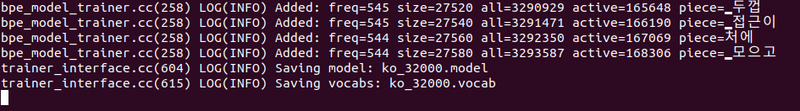

> 이미지와 같이 터미널에서 `ko_32000.model`, `ko_32000.vocab` 생성을 확인할 수 있습니다.

sentencepiece 모델 학습이 끝난 후 생성된 `ko_32000.model`, `ko_32000.vocab` 두 파일은 커널이 생성되었을 때의 홈 디렉토리에 생성되었을 것입니다. 이 두 파일을 `~/aiffel/bert_pretrain/models` 아래로 이동시킨 후 계속 진행해 주세요.



```
# 홈 디렉토리에서 아래 명령어를 입력해 주세요.
$ mv ko_32000.* ~/aiffel/bert_pretrain/models
```



In [7]:
# SentencePiece 준비 및 재사용 설정
# 기존 모델이 있으면 재학습하지 않고, 없을 때만 코퍼스 일부로 생성합니다.
import os
import sentencepiece as spm

os.makedirs('/content/models', exist_ok=True)
os.makedirs('/content/data', exist_ok=True)

corpus_file = '/content/data/kowiki.txt'
prefix = '/content/models/ko_32000'
model_path = prefix + '.model'
vocab_path = prefix + '.vocab'

if os.path.exists(model_path) and os.path.exists(vocab_path):
    print("✅ 기존 ko_32000.model / vocab을 사용합니다. 재학습을 건너뜁니다.")
else:
    sp_training_corpus = '/content/data/kowiki_sp_training.txt'
    max_lines_for_sp = 50000

    print(f"SentencePiece 학습용 축소 코퍼스 생성: 최대 {max_lines_for_sp:,}줄")
    with open(corpus_file, 'r', encoding='utf-8', errors='ignore') as src, \
         open(sp_training_corpus, 'w', encoding='utf-8') as dst:
        saved = 0
        for line in src:
            line = line.strip()
            if line:
                dst.write(line + '\n')
                saved += 1
            if saved >= max_lines_for_sp:
                break

    print(f"저장된 문장 수: {saved:,}")
    spm.SentencePieceTrainer.train(
        input=sp_training_corpus,
        model_prefix=prefix,
        vocab_size=32007,
        model_type='bpe',
        max_sentence_length=8192,
        pad_id=0, pad_piece='[PAD]',
        unk_id=1, unk_piece='[UNK]',
        bos_id=2, bos_piece='[BOS]',
        eos_id=3, eos_piece='[EOS]',
        user_defined_symbols=['[SEP]', '[CLS]', '[MASK]'],
        character_coverage=0.9995,
        num_threads=min(8, os.cpu_count() or 2),
        hard_vocab_limit=False
    )
    print("✅ 빠른 SentencePiece 생성 완료")

print("model:", model_path, os.path.exists(model_path))
print("vocab:", vocab_path, os.path.exists(vocab_path))

SentencePiece 학습용 축소 코퍼스 생성: 최대 50,000줄
저장된 문장 수: 50,000
✅ 빠른 SentencePiece 생성 완료
model: /content/models/ko_32000.model True
vocab: /content/models/ko_32000.vocab True


In [8]:
data_dir = '/content/data'
model_dir = '/content/models'

# vocab loading
vocab = spm.SentencePieceProcessor()
vocab.load(f"{model_dir}/ko_32000.model")

True

토크나이저가 잘 만들어졌는지 확인해 봅시다. 어떤 토큰이 만들어졌는지, 토크나이징 결과가 어떻게 나오는지 살펴볼까요?

In [9]:
#Q. 특수 token 7개를 제외한 나머지 token들을 출력해봅시다.
vocab_list = []
for id in range(7, len(vocab)):
        if not vocab.is_unknown(id):
            vocab_list.append(vocab.id_to_piece(id))
print(vocab_list)

['▁이', '▁1', '으로', '▁있', '에서', '▁그', '▁대', '▁사', '▁수', '▁2', '▁지', '었다', '▁기', '▁전', '▁한', '하였', '▁가', '▁있다', '▁정', '▁시', '▁아', '하는', '▁일', '▁19', '이다', '▁것', '▁중', '▁다', '했다', '▁제', '하고', '▁자', '하였다', '▁등', '▁주', '▁유', '▁인', '하여', '▁경', '▁공', '▁위', '▁보', '▁하', '▁국', '되었다', '▁동', '▁조', '▁나', '▁부', '▁고', '에는', '▁의', '00', '▁서', '▁비', '▁개', '한다', '▁연', '▁발', '▁3', '으며', '▁세', '▁때', '▁관', '▁신', '▁구', '▁소', '▁모', '▁영', '▁상', '▁여', '▁도', '▁오', '▁해', '▁미', '▁성', '적인', '▁대한', '▁않', '▁문', '▁통', '▁교', '이라', '▁내', '적으로', '▁선', '▁마', '▁또', '▁후', '▁있는', '학교', '에게', '▁생', '▁같', '▁만', '부터', '되어', '▁5', '▁강', '▁4', '▁따', '▁무', '▁거', '▁불', '▁바', '지만', '▁남', '▁반', '▁원', '▁"', '▁방', '▁당', '된다', '들이', '들은', '▁노', '▁계', '▁분', '까지', '▁결', '▁장', "▁'", '▁현', '▁어', '▁실', '▁없', '▁한다', '▁20', '▁단', '▁작', '▁프', '▁명', '하기', '▁많', '면서', '▁스', '▁받', '▁이후', '하게', '에서는', '▁독', '▁역', '▁말', '▁6', '▁사용', '▁최', '▁예', '▁진', '▁200', '▁두', '으나', '주의', '),', '▁알', '▁특', '▁군', '▁종', 'or', '▁되', '▁파', '국의', '▁포', '▁물', '▁우', '

In [10]:
# [CLS], tokens a, [SEP], tokens b, [SEP] 형태의 token 생성
string_a = "추적추적 비가 내리는 날이었어 그날은 왠지 손님이 많아 첫 번에 삼십 전 둘째번 오십 전 오랜만에 받아보는 십 전짜리 백통화 서푼에"
string_b = "손바닥 위엔 기쁨의 눈물이 흘러 컬컬한 목에 모주 한잔을 적셔 몇 달 포 전부터 콜록거리는 아내 생각에 그토록 먹고 싶다던"
tokens_org = ["[CLS]"] + vocab.encode_as_pieces(string_a) + ["[SEP]"] + vocab.encode_as_pieces(string_b) + ["[SEP]"]
print(tokens_org)

['[CLS]', '▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어', '▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁많아', '▁첫', '▁번에', '▁삼', '십', '▁전', '▁둘째', '번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜리', '▁백', '통화', '▁서', '푼', '에', '[SEP]', '▁손', '바닥', '▁위', '엔', '▁기쁨', '의', '▁눈', '물이', '▁흘러', '▁컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전부터', '▁콜', '록', '거리는', '▁아내', '▁생각에', '▁그', '토록', '▁먹고', '▁싶다', '던', '[SEP]']


토크나이저가 잘 작동하나요? 방금 우리는 SentencePiece 모델을 이용해 간단한 BERT의 Masked Language Model 학습용 데이터를 하나 생성해 보았습니다.

다음 절부터 본격적으로 데이터 전처리 과정에 돌입하겠습니다.

# 데이터 전처리 (1) MASK 생성

BERT의 Masked Language Model(MLM)은 GPT의 Next Token Prediction 태스크처럼 `다음이 이어질 단어는?` 을 맞추는 게 아니라 마스킹 된 `다음 빈칸에 알맞은 단어는?` 문제를 푸는 형식으로 구성됩니다.

MLM을 위해 BERT는 학습 데이터의 전체에서 15%를 `[MASK]` 토큰으로 랜덤하게 바꿉니다. 이 15%의 `[MASK]` 토큰 중 80%는 `[MASK]` 토큰, 10%는 무작위로 랜덤한 토큰, 나머지 10%는 원래의 토큰을 그대로 사용합니다.

이전 스텝의 Masked LM 데이터셋 예시에서 출발해 봅시다.

In [11]:
print(tokens_org)

# 전체 token의 15% mask
mask_cnt = int((len(tokens_org) - 3) * 0.15)
mask_cnt

['[CLS]', '▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어', '▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁많아', '▁첫', '▁번에', '▁삼', '십', '▁전', '▁둘째', '번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜리', '▁백', '통화', '▁서', '푼', '에', '[SEP]', '▁손', '바닥', '▁위', '엔', '▁기쁨', '의', '▁눈', '물이', '▁흘러', '▁컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전부터', '▁콜', '록', '거리는', '▁아내', '▁생각에', '▁그', '토록', '▁먹고', '▁싶다', '던', '[SEP]']


10

15%를 마스킹 한다고 해도 생각해 볼 것이 더 있습니다. Subword 기반으로 토크나이징을 했을 때 `_대, [MASK], 민국`이라고 가운데를 마스킹 했을 경우 해당 `[MASK]`가 '한'일 거라는 건 너무 쉽게 맞출 수 있습니다. '대한민국'이라는 패턴을 아주 자주 보게 될 테니까요.

그래서 Masked LM 태스크를 구성할 땐 **띄어쓰기 단위로 한꺼번에 마스킹**해 주는 것이 좋습니다. 다음과 같이 처리합니다.

In [12]:
# 띄어쓰기 단위로 mask하기 위해서 index 분할
cand_idx = []  # word 단위의 index array
for (i, token) in enumerate(tokens_org):
    if token == "[CLS]" or token == "[SEP]":
        continue
    if 0 < len(cand_idx) and not token.startswith(u"\u2581"):  # u"\u2581"는 단어의 시작을 의미하는 값
        cand_idx[-1].append(i)
    else:
        cand_idx.append([i])

# 결과확인
for cand in cand_idx:
    print(cand, [tokens_org[i] for i in cand])

[1, 2, 3] ['▁추적', '추', '적']
[4] ['▁비가']
[5] ['▁내리는']
[6, 7, 8] ['▁날', '이었', '어']
[9, 10] ['▁그날', '은']
[11, 12, 13] ['▁', '왠', '지']
[14, 15] ['▁손', '님이']
[16] ['▁많아']
[17] ['▁첫']
[18] ['▁번에']
[19, 20] ['▁삼', '십']
[21] ['▁전']
[22, 23] ['▁둘째', '번']
[24, 25] ['▁오', '십']
[26] ['▁전']
[27, 28] ['▁오랜', '만에']
[29, 30] ['▁받아', '보는']
[31] ['▁십']
[32, 33] ['▁전', '짜리']
[34, 35] ['▁백', '통화']
[36, 37, 38] ['▁서', '푼', '에']
[40, 41] ['▁손', '바닥']
[42, 43] ['▁위', '엔']
[44, 45] ['▁기쁨', '의']
[46, 47] ['▁눈', '물이']
[48] ['▁흘러']
[49, 50, 51] ['▁컬', '컬', '한']
[52, 53] ['▁목', '에']
[54, 55] ['▁모', '주']
[56, 57, 58] ['▁한', '잔', '을']
[59, 60] ['▁적', '셔']
[61] ['▁몇']
[62] ['▁달']
[63] ['▁포']
[64] ['▁전부터']
[65, 66, 67] ['▁콜', '록', '거리는']
[68] ['▁아내']
[69] ['▁생각에']
[70, 71] ['▁그', '토록']
[72] ['▁먹고']
[73, 74] ['▁싶다', '던']


In [13]:
# random mask를 위해서 index 순서를 섞음
random.shuffle(cand_idx)
cand_idx

[[18],
 [44, 45],
 [24, 25],
 [49, 50, 51],
 [31],
 [64],
 [40, 41],
 [52, 53],
 [22, 23],
 [72],
 [17],
 [19, 20],
 [61],
 [32, 33],
 [63],
 [46, 47],
 [29, 30],
 [73, 74],
 [6, 7, 8],
 [65, 66, 67],
 [68],
 [9, 10],
 [26],
 [56, 57, 58],
 [62],
 [34, 35],
 [36, 37, 38],
 [21],
 [59, 60],
 [48],
 [70, 71],
 [4],
 [27, 28],
 [42, 43],
 [14, 15],
 [69],
 [5],
 [11, 12, 13],
 [1, 2, 3],
 [16],
 [54, 55]]

개선된 Masking 로직을 다음과 같이 구현해 보았습니다. 마스킹 된 결과를 이전과 비교해 보시죠.

In [14]:
# tokens가 mask되므로 재 실행을 위해서 넣어줌 (테스트용)
tokens = copy.deepcopy(tokens_org)

mask_lms = []  # mask 된 값
for index_set in cand_idx:
    if len(mask_lms) >= mask_cnt:  # 핸재 mask된 개수가 15%를 넘으면 중지
          break
    if len(mask_lms) + len(index_set) > mask_cnt:  # 이번에 mask할 개수를 포함해 15%를 넘으면 skip
          continue
    dice = random.random()  # 0과 1 사이의 확률 값

    for index in index_set:
        masked_token = None
        if dice < 0.8:  # 80% replace with [MASK]
            masked_token = "[MASK]"
        elif dice < 0.9: # 10% keep original
            masked_token = tokens[index]
        else:  # 10% random word
            masked_token = random.choice(vocab_list)
        mask_lms.append({"index": index, "label": tokens[index]})
        tokens[index] = masked_token

print("tokens_org")
print(tokens_org, "\n")
print("tokens")
print(tokens)

tokens_org
['[CLS]', '▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어', '▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁많아', '▁첫', '▁번에', '▁삼', '십', '▁전', '▁둘째', '번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜리', '▁백', '통화', '▁서', '푼', '에', '[SEP]', '▁손', '바닥', '▁위', '엔', '▁기쁨', '의', '▁눈', '물이', '▁흘러', '▁컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전부터', '▁콜', '록', '거리는', '▁아내', '▁생각에', '▁그', '토록', '▁먹고', '▁싶다', '던', '[SEP]'] 

tokens
['[CLS]', '▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어', '▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁많아', '▁첫', '[MASK]', '▁삼', '십', '▁전', '▁둘째', '번', '[MASK]', '[MASK]', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁수소를', '▁전', '짜리', '▁백', '통화', '▁서', '푼', '에', '[SEP]', '▁손', '바닥', '▁위', '엔', '[MASK]', '[MASK]', '▁눈', '물이', '▁흘러', '[MASK]', '[MASK]', '[MASK]', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전부터', '▁콜', '록', '거리는', '▁아내', '▁생각에', '▁그', '토록', '▁먹고', '▁싶다', '던', '[SEP]']


Masked LM의 라벨 데이터도 아래와 같이 생성하여 정리해 둡니다.

In [15]:
# 순서 정렬 및 mask_idx, mask_label 생성
mask_lms = sorted(mask_lms, key=lambda x: x["index"])
mask_idx = [p["index"] for p in mask_lms]
mask_label = [p["label"] for p in mask_lms]

print("mask_idx   :", mask_idx)
print("mask_label :", mask_label)

mask_idx   : [18, 24, 25, 31, 44, 45, 49, 50, 51, 64]
mask_label : ['▁번에', '▁오', '십', '▁십', '▁기쁨', '의', '▁컬', '컬', '한', '▁전부터']


## 🔶 create_pretrain_mask() : Masked LM을 위한 코퍼스 생성 메소드
---
이번 스텝에서 구현할 최종 메소드는 아래와 같습니다.

In [16]:
# Q. 위 코드들을 참고하여 아래 함수를 완성시켜주세요.
def create_pretrain_mask(tokens, mask_cnt, vocab_list):
    """
    마스크 생성
    :param tokens: tokens
    :param mask_cnt: mask 개수 (전체 tokens의 15%)
    :param vocab_list: vocab list (random token 용)
    :return tokens: mask된 tokens
    :return mask_idx: mask된 token의 index
    :return mask_label: mask된 token의 원래 값
    """
    # 단어 단위로 mask 하기 위해서 index 분할 (띄어쓰기)
    cand_idx = []
    for (i, token) in enumerate(tokens):
        if token == "[CLS]" or token == "[SEP]":
            continue
        if 0 < len(cand_idx) and not token.startswith(u"\u2581"):
            cand_idx[-1].append(i)
        else:
            cand_idx.append([i])

    # random mask를 위해서 순서를 섞음 (shuffle)
    random.shuffle(cand_idx)
    mask_lms = []
    for index_set in cand_idx:
        if len(mask_lms) >= mask_cnt:
            break
        if len(mask_lms) + len(index_set) > mask_cnt:
            continue
        dice = random.random()
        for index in index_set:
            masked_token = None
            if dice < 0.8:
                masked_token = "[MASK]"
            elif dice < 0.9:
                masked_token = tokens[index]
            else:
                masked_token = random.choice(vocab_list)
            mask_lms.append({"index": index, "label": tokens[index]})
            tokens[index] = masked_token

    # mask_lms 정렬 후 mask_idx, mask_label 추출 (sorted 사용)
    mask_lms = sorted(mask_lms, key=lambda x: x["index"])
    mask_idx = [p["index"] for p in mask_lms]
    mask_label = [p["label"] for p in mask_lms]

    return tokens, mask_idx, mask_label

`create_pretrain_mask()` 수행 결과를 다시 한번 확인해 봅시다.

In [17]:
# tokens가 mask되므로 재 실행을 위해서 넣어줌 (테스트용)
tokens = copy.deepcopy(tokens_org)

tokens, mask_idx, mask_label = create_pretrain_mask(tokens, mask_cnt, vocab_list)

print("tokens_org")
print(tokens_org, "\n")
print("tokens")
print(tokens, "\n")

print("mask_idx   :", mask_idx)
print("mask_label :", mask_label)

tokens_org
['[CLS]', '▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어', '▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁많아', '▁첫', '▁번에', '▁삼', '십', '▁전', '▁둘째', '번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜리', '▁백', '통화', '▁서', '푼', '에', '[SEP]', '▁손', '바닥', '▁위', '엔', '▁기쁨', '의', '▁눈', '물이', '▁흘러', '▁컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전부터', '▁콜', '록', '거리는', '▁아내', '▁생각에', '▁그', '토록', '▁먹고', '▁싶다', '던', '[SEP]'] 

tokens
['[CLS]', '▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어', '▁그날', '은', '▁', '왠', '지', '▁손', '님이', '[MASK]', '[MASK]', '▁번에', '▁삼', '십', '▁전', '▁둘째', '번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜리', '▁백', '통화', '[MASK]', '[MASK]', '[MASK]', '[SEP]', '▁손', '바닥', '▁위', '엔', '▁기쁨', '의', '▁눈', '물이', '▁흘러', '▁컬', '컬', '한', '[MASK]', '[MASK]', '사', '▁대한인', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전부터', '▁콜', '록', '거리는', '[MASK]', '▁생각에', '▁그', '토록', '▁먹고', '▁싶다', '던', '[SEP]'] 

mask_idx   : [16,

# 데이터 전처리 (2) NSP pair 생성

BERT의 pretrain task로 Next Sentence Prediction이 있습니다. 문장 2개를 붙여 놓고 두 문장이 이어지는 것인지 아닌지 문장 호응관계를 맞출 수 있게 하는 것입니다.

아래와 같이 문장 A의 다음 문장이 B일 경우는 `TRUE`, 아니면 `FALSE`로 예측하게 합니다.


```
[CLS]여름의 마지막 해수욕 누가 제일 늦게 바다에서 나왔나 [SEP] 그 사람이 바다의 뚜껑 닫지 않고 돌아가[SEP] → TRUE(IsNext)

[CLS]여름의 마지막 해수욕 누가 제일 늦게 바다에서 나왔나 [SEP] 한강에서 자전거 타며 아이스아메리카노를 마시고 싶다[SEP] → FALSE(NotNext)
```
아래 문장을 예시로 진행해 보겠습니다.

In [18]:
string = """추적추적 비가 내리는 날이었어
그날은 왠지 손님이 많아
첫 번에 삼십 전 둘째 번 오십 전
오랜만에 받아보는 십 전짜리 백통화 서푼에
손바닥 위엔 기쁨의 눈물이 흘러
컬컬한 목에 모주 한잔을 적셔
몇 달 포 전부터 콜록거리는 아내
생각에 그토록 먹고 싶다던
설렁탕 한 그릇을 이제는 살 수 있어
집으로 돌아가는 길 난 문득 떠올라
아내의 목소리가 거칠어만 가는 희박한 숨소리가
오늘은 왠지 나가지 말라던 내 옆에 있어 달라던
그리도 나가고 싶으면 일찍이라도 들어와 달라던
아내의 간절한 목소리가 들려와
나를 원망하듯 비는 점점 거세져
싸늘히 식어가는 아내가 떠올라 걱정은 더해져
난 몰라 오늘은 운수 좋은 날
난 맨날 이렇게 살 수 있으면 얼마나 좋을까"""

In [19]:
# 줄 단위로 tokenize
doc = [vocab.encode_as_pieces(line) for line in string.split("\n")]
doc[:3]

[['▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어'],
 ['▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁많아'],
 ['▁첫', '▁번에', '▁삼', '십', '▁전', '▁둘째', '▁번', '▁오', '십', '▁전']]

우선 원문에서 이어진 두 문장씩 짝지어 보겠습니다.

이 단계에서 넣어줄 특수 token은 `[CLS]`와 `[SEP]`이고, sequence의 최대 길이는 `n_test_seq - 3`으로 정합니다.

In [20]:
# 최대 길이
n_test_seq = 64
# 최소 길이
min_seq = 8
# [CLS], tokens_a, [SEB], tokens_b, [SEP]
max_seq = n_test_seq - 3

In [21]:
current_chunk = []  # line 단위 tokens
current_length = 0
for i in range(len(doc)):  # doc 전체를 loop
    current_chunk.append(doc[i])  # line 단위로 추가
    current_length += len(doc[i])  # current_chunk의 token 수
    if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):  # 마지막 줄 이거나 길이가 max_seq 이상 인 경우, 학습 데이터를 만듭니다.
        print("current_chunk:", len(current_chunk), current_length, current_chunk)

        #######################################
        # token a
        a_end = 1
        if 1 < len(current_chunk):
            a_end = random.randrange(1, len(current_chunk))
        tokens_a = []
        for j in range(a_end):
            tokens_a.extend(current_chunk[j])
        # token b
        tokens_b = []
        for j in range(a_end, len(current_chunk)):
            tokens_b.extend(current_chunk[j])

        print("tokens_a:", len(tokens_a), tokens_a)
        print("tokens_b:", len(tokens_b), tokens_b)
        #######################################
        print()

        current_chunk = []
        current_length = 0

current_chunk: 7 67 [['▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어'], ['▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁많아'], ['▁첫', '▁번에', '▁삼', '십', '▁전', '▁둘째', '▁번', '▁오', '십', '▁전'], ['▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜리', '▁백', '통화', '▁서', '푼', '에'], ['▁손', '바닥', '▁위', '엔', '▁기쁨', '의', '▁눈', '물이', '▁흘러'], ['▁컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔'], ['▁몇', '▁달', '▁포', '▁전부터', '▁콜', '록', '거리는', '▁아내']]
tokens_a: 47 ['▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어', '▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁많아', '▁첫', '▁번에', '▁삼', '십', '▁전', '▁둘째', '▁번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜리', '▁백', '통화', '▁서', '푼', '에', '▁손', '바닥', '▁위', '엔', '▁기쁨', '의', '▁눈', '물이', '▁흘러']
tokens_b: 20 ['▁컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전부터', '▁콜', '록', '거리는', '▁아내']

current_chunk: 7 63 [['▁생각에', '▁그', '토록', '▁먹고', '▁싶다', '던'], ['▁설', '렁', '탕', '▁한', '▁그릇', '을', '▁이제는', '▁살', '▁수', '▁있어'], ['▁집으로', '▁돌아가는',

짝지은 두 문장을 그대로 두면 NSP task의 true label 케이스가 되고, 둘의 순서를 뒤바꾸면 false label 케이스가 되겠죠?

두 문장의 최대 길이를 유지하도록 trim을 적용한 후 50%의 확률로 true/false 케이스를 생성해 보겠습니다.

token A의 길이가 `max_seq`보다 길면 앞에서부터 토큰을 제거하고, token B의 길이가 길면 뒤에서부터 토큰을 제거합니다.

In [22]:
def trim_tokens(tokens_a, tokens_b, max_seq):
    """
    tokens_a, tokens_b의 길이를 줄임 최대 길이: max_seq
    :param tokens_a: tokens A
    :param tokens_b: tokens B
    :param max_seq: 두 tokens 길이의 최대 값
    """
    while True:
        total_length = len(tokens_a) + len(tokens_b)
        if total_length <= max_seq:
            break

        if len(tokens_a) > len(tokens_b):
            del tokens_a[0]
        else:
            tokens_b.pop()

In [23]:
current_chunk = []  # line 단위 tokens
current_length = 0
for i in range(len(doc)):  # doc 전체를 loop
    current_chunk.append(doc[i])  # line 단위로 추가
    current_length += len(doc[i])  # current_chunk의 token 수
    if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):  # 마지막 줄 이거나 길이가 max_seq 이상 인 경우
        print("current_chunk:", len(current_chunk), current_length, current_chunk)

        # token a
        a_end = 1
        if 1 < len(current_chunk):
            a_end = random.randrange(1, len(current_chunk))
        tokens_a = []
        for j in range(a_end):
            tokens_a.extend(current_chunk[j])
        # token b
        tokens_b = []
        for j in range(a_end, len(current_chunk)):
            tokens_b.extend(current_chunk[j])

        #######################################
        if random.random() < 0.5:  # 50% 확률로 swap
            is_next = 0     #False
            tokens_t = tokens_a
            tokens_a = tokens_b
            tokens_b = tokens_t
        else:
            is_next = 1    #True
        # max_seq 보다 큰 경우 길이 조절
        trim_tokens(tokens_a, tokens_b, max_seq)
        assert 0 < len(tokens_a)
        assert 0 < len(tokens_b)

        print("is_next:", is_next)
        print("tokens_a:", len(tokens_a), tokens_a)
        print("tokens_b:", len(tokens_b), tokens_b)
        #######################################
        print()

        current_chunk = []
        current_length = 0

current_chunk: 7 67 [['▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어'], ['▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁많아'], ['▁첫', '▁번에', '▁삼', '십', '▁전', '▁둘째', '▁번', '▁오', '십', '▁전'], ['▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜리', '▁백', '통화', '▁서', '푼', '에'], ['▁손', '바닥', '▁위', '엔', '▁기쁨', '의', '▁눈', '물이', '▁흘러'], ['▁컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔'], ['▁몇', '▁달', '▁포', '▁전부터', '▁콜', '록', '거리는', '▁아내']]
is_next: 1
tokens_a: 53 ['이었', '어', '▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁많아', '▁첫', '▁번에', '▁삼', '십', '▁전', '▁둘째', '▁번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜리', '▁백', '통화', '▁서', '푼', '에', '▁손', '바닥', '▁위', '엔', '▁기쁨', '의', '▁눈', '물이', '▁흘러', '▁컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔']
tokens_b: 8 ['▁몇', '▁달', '▁포', '▁전부터', '▁콜', '록', '거리는', '▁아내']

current_chunk: 7 63 [['▁생각에', '▁그', '토록', '▁먹고', '▁싶다', '던'], ['▁설', '렁', '탕', '▁한', '▁그릇', '을', '▁이제는', '▁살', '▁수', '▁있어'], ['▁집으로', '▁돌아가는', '▁길', '▁난', '▁문', '득', '▁떠올

이제 두 문장 사이에 segment 처리를 해주어야 합니다. 첫 번째 문장의 segment는 모두 0으로, 두 번째 문장은 1로 채워준 후 둘 사이에 구분자인 `[SEP]` 등을 넣어주는 것으로 마무리됩니다.

이전 스텝의 `create_pretrain_mask()`까지 함께 호출되어 Mask LM용 데이터셋과 NSP용 데이터셋이 결합된 하나의 데이터셋으로 완성될 것입니다. BERT의 pretrain은 MLM과 NSP, 두 가지 task가 동시에 수행되니까요.

In [24]:
instances = []
current_chunk = []  # line 단위 tokens
current_length = 0
for i in range(len(doc)):  # doc 전체를 loop
    current_chunk.append(doc[i])  # line 단위로 추가
    current_length += len(doc[i])  # current_chunk의 token 수
    if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):  # 마지막 줄 이거나 길이가 max_seq 이상 인 경우
        print("current_chunk:", len(current_chunk), current_length, current_chunk)

        # token a
        a_end = 1
        if 1 < len(current_chunk):
            a_end = random.randrange(1, len(current_chunk))
        tokens_a = []
        for j in range(a_end):
            tokens_a.extend(current_chunk[j])
        # token b
        tokens_b = []
        for j in range(a_end, len(current_chunk)):
            tokens_b.extend(current_chunk[j])

        if random.random() < 0.5:  # 50% 확률로 swap
            is_next = 0    # False
            tokens_t = tokens_a
            tokens_a = tokens_b
            tokens_b = tokens_t
        else:
            is_next = 1   # True
        # max_seq 보다 큰 경우 길이 조절
        trim_tokens(tokens_a, tokens_b, max_seq)
        assert 0 < len(tokens_a)
        assert 0 < len(tokens_b)

        print("is_next:", is_next)
        print("tokens_a:", len(tokens_a), tokens_a)
        print("tokens_b:", len(tokens_b), tokens_b)
        #######################################

        # tokens & segment 생성
        tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
        segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)
        print("tokens:", len(tokens), tokens)
        print("segment:", len(segment), segment)

        # mask
        tokens, mask_idx, mask_label = create_pretrain_mask(tokens, int((len(tokens) - 3) * 0.15), vocab_list)
        print("masked tokens:", len(tokens), tokens)
        print("masked index:", len(mask_idx), mask_idx)
        print("masked label:", len(mask_label), mask_label)

        instance = {
            "tokens": tokens,
            "segment": segment,
            "is_next": is_next,
            "mask_idx": mask_idx,
            "mask_label": mask_label
        }
        instances.append(instance)
        #######################################
        print()

        current_chunk = []
        current_length = 0

current_chunk: 7 67 [['▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어'], ['▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁많아'], ['▁첫', '▁번에', '▁삼', '십', '▁전', '▁둘째', '▁번', '▁오', '십', '▁전'], ['▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜리', '▁백', '통화', '▁서', '푼', '에'], ['▁손', '바닥', '▁위', '엔', '▁기쁨', '의', '▁눈', '물이', '▁흘러'], ['▁컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔'], ['▁몇', '▁달', '▁포', '▁전부터', '▁콜', '록', '거리는', '▁아내']]
is_next: 0
tokens_a: 29 ['▁손', '바닥', '▁위', '엔', '▁기쁨', '의', '▁눈', '물이', '▁흘러', '▁컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전부터', '▁콜', '록', '거리는', '▁아내']
tokens_b: 32 ['▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어', '▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁많아', '▁첫', '▁번에', '▁삼', '십', '▁전', '▁둘째', '▁번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '▁전']
tokens: 64 ['[CLS]', '▁손', '바닥', '▁위', '엔', '▁기쁨', '의', '▁눈', '물이', '▁흘러', '▁컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전부터', 

In [25]:
# 최종 데이터셋 결과 확인
for instance in instances:
    print(instance)

{'tokens': ['[CLS]', '▁손', '바닥', '▁위', '엔', '▁기쁨', '의', '▁눈', '물이', '▁흘러', '▁컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전부터', '▁콜', '록', '거리는', '[MASK]', '[SEP]', '▁추적', '추', '적', '▁하게', '▁내리는', '[MASK]', '[MASK]', '[MASK]', '▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁많아', '▁첫', '▁번에', '▁삼', '십', '▁전', '[MASK]', '▁번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '[MASK]', '[SEP]'], 'segment': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'is_next': 0, 'mask_idx': [20, 21, 29, 34, 36, 37, 38, 52, 62], 'mask_label': ['▁적', '셔', '▁아내', '▁비가', '▁날', '이었', '어', '▁둘째', '▁전']}
{'tokens': ['[CLS]', '토록', '▁먹고', '▁싶다', '던', '▁설', '렁', '탕', '▁한', '▁그릇', '을', '▁처녀', '[MASK]', '[MASK]', '[MASK]', '▁집으로', '▁돌아가는', '▁길', '▁난', '▁문', '득', '▁떠올', '라', '▁아내의', '▁목소리가', '異', '섣', '위와', '▁가는', '[MASK]', '[MASK]', '▁숨',

## 🔶 create_pretrain_instances() : Next Sentence Prediction을 위한 코퍼스 생성 메소드
---
이번 스텝에서 구현할 최종 메소드는 아래와 같습니다.

In [26]:
# Q. 위 코드들을 참고하여 아래 함수를 완성시켜주세요.
def create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list):
    """
    doc별 pretrain 데이터 생성
    """
    # for CLS], [SEP], [SEP]
    max_seq = n_seq - 3

    instances = []
    current_chunk = []
    current_length = 0
    for i in range(len(doc)):

        current_chunk.append(doc[i])
        current_length += len(doc[i])
        if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):
            a_end = 1
            if 1 < len(current_chunk):
                a_end = random.randrange(1, len(current_chunk))
            tokens_a = []
            for j in range(a_end):
                tokens_a.extend(current_chunk[j])
            tokens_b = []
            for j in range(a_end, len(current_chunk)):
                tokens_b.extend(current_chunk[j])

            if random.random() < 0.5:
                is_next = 0
                tokens_t = tokens_a
                tokens_a = tokens_b
                tokens_b = tokens_t
            else:
                is_next = 1
            trim_tokens(tokens_a, tokens_b, max_seq)
            assert 0 < len(tokens_a)
            assert 0 < len(tokens_b)
            tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
            segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)
            tokens, mask_idx, mask_label = create_pretrain_mask(tokens, int((len(tokens) - 3) * mask_prob), vocab_list)

            instance = {
                "tokens": tokens,
                "segment": segment,
                "is_next": is_next,
                "mask_idx": mask_idx,
                "mask_label": mask_label
            }
            instances.append(instance)

            current_chunk = []
            current_length = 0
    return instances

`create_pretrain_instances()` 수행 결과를 다시 한번 확인해 봅시다.

In [27]:
instances = create_pretrain_instances(vocab, doc, n_test_seq, 0.15, vocab_list)

# 최종 데이터셋 결과 확인
for instance in instances:
    print(instance)

{'tokens': ['[CLS]', '▁손', '바닥', '[MASK]', '[MASK]', '▁기쁨', '의', '▁눈', '물이', '▁흘러', '▁컬', '컬', '한', '▁목', '에', '[MASK]', '[MASK]', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전부터', '▁콜', '록', '거리는', '▁아내', '[SEP]', '▁추적', '추', '적', '▁비가', '▁내리는', '[MASK]', '[MASK]', '[MASK]', '▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁많아', '▁첫', '▁번에', '▁삼', '십', '[MASK]', '▁둘째', '▁번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '속을', '[SEP]'], 'segment': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'is_next': 0, 'mask_idx': [3, 4, 15, 16, 36, 37, 38, 51, 62], 'mask_label': ['▁위', '엔', '▁모', '주', '▁날', '이었', '어', '▁전', '▁전']}
{'tokens': ['[CLS]', '▁거칠', '어', '만', '▁가는', '▁희', '박한', '▁숨', '소리가', '▁오늘', '은', '▁', '왠', '지', '▁나가지', '▁말라', '던', '▁내', '▁옆에', '▁있어', '▁달라', '던', '▁그리', '도', '▁나가고', '[MASK]', '[MASK]', '▁일찍', '이라도', '▁들어와', '총', '▁독주', '▁아내의

# 데이터 전처리 (3) 데이터셋 완성

이제 우리가 다루어야 할 `kowiki.txt`에 대해 본격적으로 들여다보겠습니다.

In [28]:
corpus_file = '/content/data/kowiki.txt'

# line count 확인
total = 0
with open(corpus_file, 'r') as in_f:
    for line in in_f:
        total += 1

total

3957761

전체 라인 수가 확인되시나요? 거의 400만 개에 육박하는 수치입니다.

위키 문서는 하나의 도큐먼트가 주제 키워드에 대해 상세 내용이 설명으로 따라붙어 있는 형태로 구성되어 있지요? 도큐먼트 주제별로 잘 나눠지는지도 확인해 보겠습니다.

In [29]:
# 위키가 주제별로 잘 나눠지는지 여부 확인
count = 5

with open(corpus_file, 'r') as in_f:
    doc = []  # 단락 단위로 문서 저장
    for line in tqdm(in_f, total=total):
        line = line.strip()
        if line == "":  # line이 빈줄 일 경우 (새로운 단락)
            if 0 < len(doc):
                if 0 < count:
                    count -= 1
                    print(len(doc), "lines :", doc[0])
                    print(doc[1])
                    print(doc[-1])
                    print()
                else:
                    break
                doc = []
        else:  # 빈 줄이 아니면 doc에 저장
            pieces = vocab.encode_as_pieces(line)
            if 0 < len(pieces):
                doc.append(pieces)
    if 0 < len(doc):  # 마지막에 처리되지 않은 doc가 있는 경우
        print(doc[0])
        print(doc[1])
        print(doc[-1])
        doc = []

  0%|          | 0/3957761 [00:00<?, ?it/s]

21 lines : ['▁지미', '▁카터']
['▁제임스', '▁얼', '▁"', '지', '미', '"', '▁카터', '▁주', '니어', '(,', '▁1924', '년', '▁10', '월', '▁1', '일', '▁~', '▁)', '는', '▁민주당', '▁출신', '▁미국', '▁39', '번째', '▁대통령', '▁(19', '77', '년', '▁~', '▁1981', '년', ')', '이다', '.']
['▁그는', '▁2002', '년', '▁말', '▁인권', '과', '▁중재', '▁역할에', '▁대한', '▁공', '로를', '▁인정받아', '▁노벨', '▁평화', '상을', '▁받게', '▁되었다', '.']

14 lines : ['▁수학']
['▁수학', '(', '數', '學', ',', '▁)', '은', '▁양', ',', '▁구조', ',', '▁공간', ',', '▁변화', ',', '▁미적분', '▁등의', '▁개념을', '▁다루는', '▁학문이다', '.', '▁현대', '▁수', '학은', '▁형식', '▁논리를', '▁이용해서', '▁공', '리로', '▁구성된', '▁추상적', '▁구조를', '▁연구하는', '▁학문으로', '▁여겨', '지기도', '▁한다', '.', '▁수', '학은', '▁그', '▁구조와', '▁발전', '▁과정', '에서는', '▁자연과학', '에', '▁속하는', '▁물리학을', '▁비롯한', '▁다른', '▁학문', '들과', '▁깊은', '▁연', '관을', '▁맺고', '▁있다', '.', '▁하지만', ',', '▁어느', '▁과학의', '▁분야', '들과는', '▁달리', ',', '▁자연', '계에서', '▁관측', '되지', '▁않는', '▁개념', '들에', '▁대해서', '까지', '▁이론을', '▁일반화', '▁및', '▁추상', '화', '시킬', '▁수', '▁있다는', '▁차이가', '▁있다고', '▁한다', '.', '▁수학자들은', '▁그러한', '▁개념'

이전 스텝에서 완성했던 `create_pretrain_instances()`를 코퍼스에 적용할 수 있는지 몇 라인에 대해서만 확인해 봅시다.

In [30]:
# instance 생성 기능 확인
count = 5

with open(corpus_file, 'r') as in_f:
    doc = []  # 단락 단위로 문서 저장
    for line in tqdm(in_f, total=total):
        line = line.strip()
        if line == "":  # line이 빈줄 일 경우 (새로운 단락)
            if 0 < len(doc):
                instances = create_pretrain_instances(vocab, doc, n_test_seq, 0.15, vocab_list)
                # save
                print("doc:", len(doc), "instances:", len(instances))
                print(instances[0])
                print(instances[-1])
                print()
                doc = []
                if 0 < count:  # 테스트를 위해서 부분 처리함
                    count -= 1
                else:
                    break
        else:  # doc에 저장
            if 0 < len(pieces):
                doc.append(pieces)
    if 0 < len(doc):  # 마지막에 처리되지 않은 doc가 있는 경우
        instances = create_pretrain_instances(doc, 128)
        # save
        print("doc:", len(doc), "instances:", len(instances))
        print(instances[0])
        print(instances[-1])
        print()
        doc = []

  0%|          | 0/3957761 [00:00<?, ?it/s]

doc: 21 instances: 10
{'tokens': ['[CLS]', '▁X', '선', '▁결정', '학', '▁등이', '[MASK]', '▁유기', '▁화합물', '▁분석에', '▁있어서', '▁매우', '▁중요한', '[MASK]', '▁자리잡았다', '.', '[MASK]', '[MASK]', '▁합성', '섬', '유', '등의', '▁고분', '자', '물질', '▁등도', '▁유기', '화', '학에서', '▁다루', '어진다', '.', '[SEP]', '[MASK]', '[MASK]', '[MASK]', '▁탄', '소로', '▁이루어진', '▁화합물을', '▁연구하는', '▁분과', '이다', '.', '▁원래', '▁유기', '[MASK]', '▁식물', '이나', '▁동물', '로부터', '▁추출', '해', '낸', '▁화합물을', '▁뜻', '하였으나', '▁지금은', '▁유기', '[MASK]', '▁범위가', '▁크게', '▁넓', '[SEP]'], 'segment': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'is_next': 0, 'mask_idx': [6, 13, 16, 17, 33, 34, 35, 46, 59], 'mask_label': ['▁개발되어', '▁방법으로', '▁플라스틱', ',', '▁유기', '화', '학은', '▁화합물은', '▁화합물의']}
{'tokens': ['[CLS]', '▁X', '선', '▁결정', '학', '▁등이', '▁개발되어', '▁유기', '▁화합물', '[MASK]', '[MASK]', '▁매우', '▁중요한', '▁방법으로', '▁자리잡았다', '.', '▁플라스틱', ',

## 🔶 make_pretrain_data() : BERT pretrain 데이터셋 생성 메소드
---
전체 전처리 과정을 거쳐 최종적으로 만들어지는 BERT pretrain 데이터셋 생성 메소드는 다음과 같습니다.

In [31]:
# Q. 아래 주석에 따라 코드를 완성해주세요.
def make_pretrain_data(vocab, in_file, out_file, n_seq, mask_prob=0.15):
    """ pretrain 데이터 생성 """
    def save_pretrain_instances(out_f, doc):
        instances = create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list)
        for instance in instances:
            out_f.write(json.dumps(instance, ensure_ascii=False))
            out_f.write("\n")

    # 특수문자 7개를 제외한 vocab_list 생성
    vocab_list = []
    for id in range(7, len(vocab)):
        if not vocab.is_unknown(id):        # 생성되는 단어 목록이 unknown인 경우는 제거합니다.
            vocab_list.append(vocab.id_to_piece(id))

    # line count 확인
    line_cnt = 0
    with open(in_file, "r") as in_f:
        for line in in_f:
            line_cnt += 1

    with open(in_file, "r") as in_f:
        with open(out_file, "w") as out_f:
            doc = []
            for line in tqdm(in_f, total=line_cnt):
                line = line.strip()
                if line == "":  # line이 빈줄 일 경우 (새로운 단락)
                    if 0 < len(doc):
                        save_pretrain_instances(out_f, doc)
                        doc = []
                else:  # line이 빈줄이 아닐 경우 tokenize 해서 doc에 저장
                    pieces = vocab.encode_as_pieces(line)
                    if 0 < len(pieces):
                        doc.append(pieces)
            if 0 < len(doc):  # 마지막에 처리되지 않은 doc가 있는 경우
                save_pretrain_instances(out_f, doc)
                doc = []

이제 약 400만 라인에 해당하는 전체 코퍼스에 대해 `make_pretrain_data()`를 구동해 봅시다. 10여 분 가량 시간이 소요될 수 있습니다.  
최종적으로 생성된 데이터셋은 json 포맷으로 저장될 것입니다.

In [32]:
pretrain_json_path = '/content/data/bert_pre_train.json'

make_pretrain_data(vocab, corpus_file, pretrain_json_path, 128)

  0%|          | 0/3957761 [00:00<?, ?it/s]

In [33]:
# 라인수
total = 0
with open(pretrain_json_path, "r") as f:
    for line in f:
        total += 1
total

868455

데이터셋 파일을 만드는 것까지 수행되었습니다.

하지만 여기서 고려해야 할 점이 있습니다. 우리가 다루어야 할 데이터셋은 사이즈가 큽니다. 만들어질 json 데이터파일의 크기가 1.4GB 정도 됩니다. 실제 BERT 학습용의 백 분의 일 사이즈 정도밖에 안 되겠지만 그럼에도 불구하고 이렇게 큰 파일을 로딩하는 함수를 만들 때는 메모리 사용량과 관련해 고려해야 할 점이 있습니다.

그래서 우리는 `np.memmap`을 사용해서 메모리 사용량을 최소화하는 방법을 시도해 볼 것입니다.

In [34]:
n_seq = 128
# [CLS], tokens_a, [SEP], tokens_b, [SEP]
max_seq = n_seq - 3

# 만약 일반적인 Numpy Array에다 데이터를 로딩한다면 이렇게 되겠지만
# enc_tokens = np.zeros((total, n_seq), np.int32)
# dec_tokens = np.zeros((total, n_seq), np.int32)
# labels_nsp = np.zeros((total,), np.int32)
# labels_mlm = np.zeros((total, n_seq), np.int32)

# np.memmap을 사용하면 메모리를 적은 메모리에서도 대용량 데이터 처리가 가능 함
enc_tokens = np.memmap(filename='enc_tokens.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
segments = np.memmap(filename='segments.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
labels_nsp = np.memmap(filename='labels_nsp.memmap', mode='w+', dtype=np.int32, shape=(total,))
labels_mlm = np.memmap(filename='labels_mlm.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))


enc_tokens[0], enc_tokens[-1], segments[0], segments[-1], labels_nsp[0], labels_nsp[-1], labels_mlm[0], labels_mlm[-1]

(memmap([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32),
 memmap([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32),
 memmap([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0

만들어진 json 파일을 라인 단위로 읽어 들여 `np.memmap`에 로딩해 봅시다.

In [35]:
# 라인 단위로 처리
with open(pretrain_json_path, "r") as f:
    for i, line in enumerate(tqdm(f, total=total)):
        if 5 < i:  # 테스트를 위해서 5개만 확인
            break
        data = json.loads(line)
        # encoder token
        enc_token = [vocab.piece_to_id(p) for p in data["tokens"]]
        enc_token += [0] * (n_seq - len(enc_token))
        # segment
        segment = data["segment"]
        segment += [0] * (n_seq - len(segment))
        # nsp label
        label_nsp = data["is_next"]
        # mlm label
        mask_idx = np.array(data["mask_idx"], dtype=int)
        mask_label = np.array([vocab.piece_to_id(p) for p in data["mask_label"]], dtype=int)
        label_mlm = np.full(n_seq, dtype=int, fill_value=0)
        label_mlm[mask_idx] = mask_label

        print(data)
        print("enc_token:", enc_token)
        print("segment:", segment)
        print("label_nsp:", label_nsp)
        print("label_mlm:", label_mlm)
        print()

        assert len(enc_token) == len(segment) == len(label_mlm) == n_seq

        enc_tokens[i] = enc_token
        segments[i] = segment
        labels_nsp[i] = label_nsp
        labels_mlm[i] = label_mlm

  0%|          | 0/868455 [00:00<?, ?it/s]

{'tokens': ['[CLS]', '▁공과', '대학교를', '▁졸업하였다', '.', '▁그', '[MASK]', '▁해', '군에', '▁들어가', '▁전', '함', '·', '원자력', '·', '잠', '수', '함의', '▁승', '무', '원으로', '▁일', '하였다', '.', '▁1953', '년', '▁미국', '▁해군', '▁대', '위로', '▁예편', '하였고', '[MASK]', 'ement', '분계', '▁극좌표', '▁등록되어', '정치적', '▁등을', '▁가', '꿔', '▁많은', '[MASK]', '▁벌', '었다', '.', '▁그의', '▁별명이', '▁"', '땅', '콩', '▁농부', '"', '▁(', 'P', 'ean', 'ut', '▁F', 'ar', 'mer', ')', '로', '▁알려졌다', '.', '[SEP]', '▁1962', '년', '▁조지아', '▁주', '▁상원', '▁의원', '[MASK]', '▁낙선', '하나', '▁그', '▁선거가', '▁부정선거', '▁', '였', '음을', '▁입증', '하게', '▁되어', '▁칼리굴', '▁하천의', '▁6,000', '▁1966', '년', '▁조지아', '▁주', '▁지사', '▁선거에', '▁낙선', '하지만', '▁1970', '년', '▁조지아', '▁주', '▁출토', '▁장소', '▁역임했다', '.', '▁대통령이', '▁되기', '▁전', '▁조지아', '주', '▁상원의', '원을', '▁두', '번', '▁연임', '했으며', ',', '▁1971', '년부터', '▁1975', '년까지', '▁조지아', '▁지', '사로', '[MASK]', '[MASK]', '[MASK]', '▁조지아', '▁주지', '사로', '[SEP]'], 'segment': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

## 🔶 load_pre_train_data() : 학습에 필요한 데이터를 로딩하는 함수
---
`np.memmap`을 사용해 메모리 효율적으로 만들어진 데이터를 로딩하는 함수를 아래와 같이 구성하였습니다.

In [36]:
def load_pre_train_data(vocab, filename, n_seq, count=None):
    """
    학습에 필요한 데이터를 로드
    :param vocab: vocab
    :param filename: 전처리된 json 파일
    :param n_seq: 시퀀스 길이 (number of sequence)
    :param count: 데이터 수 제한 (None이면 전체)
    :return enc_tokens: encoder inputs
    :return segments: segment inputs
    :return labels_nsp: nsp labels
    :return labels_mlm: mlm labels
    """
    total = 0
    with open(filename, "r") as f:
        for line in f:
            total += 1
            # 데이터 수 제한
            if count is not None and count <= total:
                break

    # np.memmap을 사용하면 메모리를 적은 메모리에서도 대용량 데이터 처리가 가능 함
    enc_tokens = np.memmap(filename='enc_tokens.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
    segments = np.memmap(filename='segments.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
    labels_nsp = np.memmap(filename='labels_nsp.memmap', mode='w+', dtype=np.int32, shape=(total,))
    labels_mlm = np.memmap(filename='labels_mlm.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))

    with open(filename, "r") as f:
        for i, line in enumerate(tqdm(f, total=total)):
            if total <= i:
                print("data load early stop", total, i)
                break
            data = json.loads(line)
            # encoder token
            enc_token = [vocab.piece_to_id(p) for p in data["tokens"]]
            enc_token += [0] * (n_seq - len(enc_token))
            # segment
            segment = data["segment"]
            segment += [0] * (n_seq - len(segment))
            # nsp label
            label_nsp = data["is_next"]
            # mlm label
            mask_idx = np.array(data["mask_idx"], dtype=np.int32)
            mask_label = np.array([vocab.piece_to_id(p) for p in data["mask_label"]], dtype=np.int32)
            label_mlm = np.full(n_seq, dtype=np.int32, fill_value=0)
            label_mlm[mask_idx] = mask_label

            assert len(enc_token) == len(segment) == len(label_mlm) == n_seq

            enc_tokens[i] = enc_token
            segments[i] = segment
            labels_nsp[i] = label_nsp
            labels_mlm[i] = label_mlm

    return (enc_tokens, segments), (labels_nsp, labels_mlm)

In [37]:
# 128000건만 메모리에 로딩
pre_train_inputs, pre_train_labels = load_pre_train_data(vocab, pretrain_json_path, 128, count=128000)

  0%|          | 0/128000 [00:00<?, ?it/s]

data load early stop 128000 128000


In [38]:
# 처음과 마지막 확인
pre_train_inputs[0][0], pre_train_inputs[0][-1], pre_train_inputs[1][0], pre_train_inputs[1][-1], pre_train_labels[0][0], pre_train_labels[0][-1], pre_train_labels[1][0], pre_train_labels[1][-1]

(memmap([    5, 12065, 21314, 15334, 28503,    12,     6,    80,  1694,
          2639,    20, 28690, 28685, 22632, 28685, 29118, 28534, 18441,
           396, 28628,  1200,    29,    39, 28503,  4711, 28530,   293,
          4670,    13,  2580, 19066,   384,     6, 14579, 20150, 11375,
         22959, 19740,   476,    23, 29745,   295,     6,   778,    18,
         28503,   231, 21952,   116, 29145, 29279, 13223, 28621,   223,
         28813, 17894,  2436,   828,   575,  9089, 28527, 28507,  5213,
         28503,     4,  4064, 28530, 11036,    41, 24320,  1975,     6,
         11297,  2883,    12, 14170, 15646, 28498, 28560,   809,  6374,
           145,   633, 19309, 22087, 22247,  6675, 28530, 11036,    41,
         24393,  8160, 11297,  1497,  1953, 28530, 11036,    41, 11703,
          7793, 19384, 28503,  2609,  5935,    20, 11036, 28549, 19850,
           682,   156, 28743, 20306,   695, 28506,  4380,   670,  4275,
           926, 11036,    17,  1274,     6,     6,     6, 11036,

# BERT 모델 구현

이제 본격적으로 BERT model을 구현해 보겠습니다.

BERT가 transformer encoder로 구현되어 있다는 것은 잘 알고 계시리라 생각합니다. 이미 여러 번 다뤄보셨을 transformer의 모델 구조와 거의 유사하지만, 아래 그림과 같이 3개의 embedding 레이어를 가진다는 점에 유의해야 합니다.

각 embedding의 자세한 구현 방법은 아래의 자료를 참고하세요.

  - [BERT 내의 Positional Embedding Layer 구현하기](https://modulabs.co.kr/blog/bert-positional-embedding-layer)

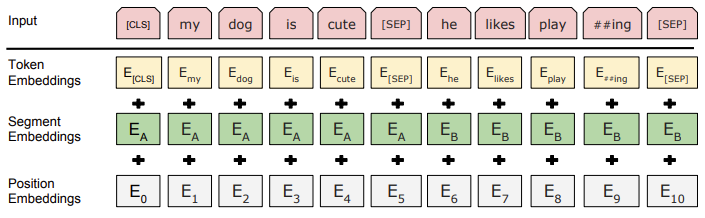

우선 몇 가지 유틸리티 함수를 정의하겠습니다.

In [39]:
def get_pad_mask(tokens, i_pad=0):
    """
    pad mask 계산하는 함수
    :param tokens: tokens (bs, n_seq)
    :param i_pad: id of pad
    :return mask: pad mask (pad: 1, other: 0)
    """
    mask = (tokens == i_pad).float()
    mask = mask.unsqueeze(1)
    return mask

def get_ahead_mask(tokens, i_pad=0):
    """
    ahead mask 계산하는 함수
    :param tokens: tokens (bs, n_seq)
    :param i_pad: id of pad
    :return mask: ahead and pad mask (ahead or pad: 1, other: 0)
    """
    n_seq = tokens.size(1)
    ahead_mask = 1 - torch.tril(torch.ones((n_seq, n_seq)))
    ahead_mask = ahead_mask.unsqueeze(0)
    pad_mask = get_pad_mask(tokens, i_pad)
    mask = torch.maximum(ahead_mask, pad_mask)
    return mask

print("슝=3")

슝=3


여기서는 ReLU가 아닌 GELU를 사용하겠습니다. 일반적으로 GELU는 ReLU나 ELU보다 성능이 좋다고 합니다. 아래의 그래프는 [GELU 논문](https://arxiv.org/pdf/1606.08415)에 나온 GELU, ReLU, ELU 함수를 비교하여 나타낸 것입니다.

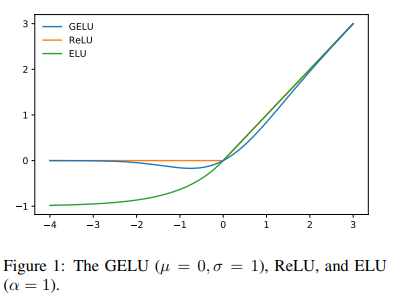


[GELU, ReLU, ELU 함수]

 https://arxiv.org/pdf/1606.08415.pdf

GELU 함수의 식은 GELU 함수 아래와 같습니다.

$$0.5 \times \left( 1 + \tanh \left[ \sqrt{2/\pi} (x + 0.044715x^3) \right] \right)$$

In [40]:
def gelu(x):
    """
    gelu activation 함수
    :param x: 입력 값
    :return: gelu activation result
    """
    return 0.5 * x * (1 + torch.tanh(math.sqrt(2 / math.pi) * (x + 0.044715 * torch.pow(x, 3))))

print("슝=3")

슝=3


In [41]:
def kernel_initializer(stddev=0.02):
    """
    parameter initializer 생성
    :param stddev: 생성할 랜덤 변수의 표준편차
    """
    return torch.nn.init.trunc_normal_

def bias_initializer():
    """
    bias initializer 생성
    """
    return torch.zeros_

print("슝=3")

슝=3


In [42]:
class Config(dict):
    """
    json을 config 형태로 사용하기 위한 Class
    :param dict: config dictionary
    """
    __getattr__ = dict.__getitem__
    __setattr__ = dict.__setitem__

    @classmethod
    def load(cls, file):
        """
        file에서 Config를 생성 함
        :param file: filename
        """
        with open(file, 'r') as f:
            config = json.loads(f.read())
            return Config(config)
print("슝=3")

슝=3


이제 본격적으로 embedding 레이어를 쌓아나가겠습니다. 아래는 Token Embedding의 구현입니다.

In [43]:
class SharedEmbedding(nn.Module):
    """
    Weighed Shared Embedding Class
    """
    def __init__(self, config, name="weight_shared_embedding"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.n_vocab = config.n_vocab
        self.d_model = config.d_model
        self.shared_weights = nn.Parameter(torch.empty(self.n_vocab, self.d_model))
        nn.init.trunc_normal_(self.shared_weights, std=0.02)  # TensorFlow와 동일한 초기화 적용

    def forward(self, inputs, mode="embedding"):
        """
        layer 실행
        :param inputs: 입력
        :param mode: 실행 모드
        :return: embedding or linear 실행 결과
        """
        # mode가 embedding일 경우 embedding lookup 실행
        if mode == "embedding":
            return self._embedding(inputs)
        # mode가 linear일 경우 linear 실행
        elif mode == "linear":
            return self._linear(inputs)
        # mode가 기타일 경우 오류 발생
        else:
            raise ValueError(f"mode {mode} is not valid.")

    def _embedding(self, inputs):
        """
        embedding lookup
        :param inputs: 입력
        """
        inputs = torch.clamp(inputs, max=self.shared_weights.size(0) - 1)

        return self.shared_weights[inputs.long()]

    def _linear(self, inputs):  # (bs, n_seq, d_model)
        """
        linear 실행
        :param inputs: 입력
        """
        n_batch, n_seq, _ = inputs.shape
        inputs = inputs.view(-1, self.d_model)  # (bs * n_seq, d_model)
        outputs = torch.matmul(inputs, self.shared_weights.T)
        outputs = outputs.view(n_batch, n_seq, self.n_vocab)  # (bs, n_seq, n_vocab)
        return outputs
print("슝=3")

슝=3


Position Embedding 레이어는 다음과 같습니다.

Transformer이 사인 함수와 코사인 함수를 이용한 Positional Encoding을 통해 토큰의 상대적인 위치를 학습했던 것과 달리, BERT에서는 Position Embedding을 사용합니다. Position Embedding은 위치 정보가 담긴 임베딩 레이어를 하나 더 사용해 Position Embedding 벡터를 학습시켜서, BERT의 입력에 Position Embedding을 더해줍니다.

In [44]:
class PositionEmbedding(nn.Module):
    """
    Position Embedding Class
    """
    def __init__(self, config, name="position_embedding"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.embedding = nn.Embedding(config.n_seq, config.d_model)
        nn.init.trunc_normal_(self.embedding.weight, std=0.02)

    def forward(self, inputs):
        """
        layer 실행
        :param inputs: 입력
        :return embed: position embedding lookup 결과
        """
        position = torch.cumsum(torch.ones_like(inputs), dim=1) - 1
        position = position.long()
        embed = self.embedding(position)
        return embed

print("슝=3")

슝=3


상대적으로 매우 간단한 Segment Embedding은 별도의 레이어를 구현하지 않고 BERT 클래스에서 간단히 포함하도록 하겠습니다. Segment Embedding는 두 개의 문장을 구분하기 위한 임베딩이었던 것은 기억나시죠?

아래는 Transformer에서 자주 보았던 `ScaleDotProductAttention`과 이를 활용한 `MultiHeadAttention`입니다.

In [45]:
class ScaleDotProductAttention(nn.Module):
    """
    Scale Dot Product Attention Class
    """
    def __init__(self, name="scale_dot_product_attention"):
        """
        생성자
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

    def forward(self, Q, K, V, attn_mask):
        """
        layer 실행
        :param Q: Q value
        :param K: K value
        :param V: V value
        :param attn_mask: 실행 모드
        :return attn_out: attention 실행 결과
        """
        attn_score = torch.matmul(Q, K.transpose(-2, -1))
        scale = torch.sqrt(torch.tensor(K.shape[-1], dtype=torch.float32))
        attn_scale = attn_score / scale
        attn_scale = attn_scale - (attn_mask * 1e9)
        attn_prob = F.softmax(attn_scale, dim=-1)
        attn_out = torch.matmul(attn_prob, V)
        return attn_out

print("슝=3")

슝=3


In [46]:
# Q. 주석과 코드를 참조하여 아래 클래스를 완성해주세요.
class MultiHeadAttention(nn.Module):
    """
    Multi Head Attention Class
    """
    def __init__(self, config, name="multi_head_attention"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.d_model = config.d_model
        self.n_head = config.n_head
        self.d_head = config.d_head

        # Q, K, V input dense layer
        self.W_Q = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_K = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_V = nn.Linear(config.d_model, config.n_head * config.d_head)
        # Scale Dot Product Attention class
        self.attention = ScaleDotProductAttention()
        # output dense layer
        self.W_O = nn.Linear(config.n_head * config.d_head, config.d_model)

    def forward(self, Q, K, V, attn_mask):
        """
        layer 실행
        :param Q: Q value
        :param K: K value
        :param V: V value
        :param attn_mask: 실행 모드
        :return attn_out: attention 실행 결과
        """
        batch_size = Q.shape[0]

        # reshape Q, K, V, attn_mask
        Q_m = self.W_Q(Q).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        K_m = self.W_K(K).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        V_m = self.W_V(V).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        attn_mask_m = attn_mask.unsqueeze(1)

        # Scale Dot Product Attention 실행
        attn_out = self.attention(Q_m, K_m, V_m, attn_mask_m)
        # (batch_size, n_seq, n_head, d_head)로 변환 후, (batch_size, n_seq, d_model)로 reshape
        attn_out_m = attn_out.transpose(1, 2).contiguous()  # (batch_size, n_seq, n_head, d_head)
        attn_out = attn_out_m.view(batch_size, -1, self.n_head * self.d_head)  # (batch_size, n_seq, d_model)
        attn_out = self.W_O(attn_out)  # (batch_size, n_seq, d_model)

        return attn_out
print("슝=3")

슝=3


<details>
<summary>예시코드</summary>
<div markdown="1">



```
class MultiHeadAttention(nn.Module):
    """
    Multi Head Attention Class
    """
    def __init__(self, config, name="multi_head_attention"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.d_model = config.d_model
        self.n_head = config.n_head
        self.d_head = config.d_head

        # Q, K, V input dense layer
        self.W_Q = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_K = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_V = nn.Linear(config.d_model, config.n_head * config.d_head)
        # Scale Dot Product Attention class
        self.attention = ScaleDotProductAttention()
        # output dense layer
        self.W_O = nn.Linear(config.n_head * config.d_head, config.d_model)

    def forward(self, Q, K, V, attn_mask):
        """
        layer 실행
        :param Q: Q value
        :param K: K value
        :param V: V value
        :param attn_mask: 실행 모드
        :return attn_out: attention 실행 결과
        """
        batch_size = Q.shape[0]

        # reshape Q, K, V, attn_mask
        Q_m = self.W_Q(Q).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        K_m = self.W_K(K).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        V_m = self.W_V(V).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)

        # attn_mask 변환
        attn_mask_m = attn_mask.unsqueeze(1)
        # Scale Dot Product Attention 실행
        attn_out = self.attention(Q_m, K_m, V_m, attn_mask_m)
        # (batch_size, n_seq, n_head, d_head)로 변환 후, (batch_size, n_seq, d_model)로 reshape
        attn_out_m = attn_out.transpose(1, 2).contiguous()  # (batch_size, n_seq, n_head, d_head)
        attn_out = attn_out_m.view(batch_size, -1, self.n_head * self.d_head)  # (batch_size, n_seq, d_model)
        attn_out = self.W_O(attn_out)  # (batch_size, n_seq, d_model)
        
        return attn_out
print("슝=3")
```



</div>
</details>

이를 바탕으로 transformer encoder 레이어를 구성하겠습니다.

In [47]:
class PositionWiseFeedForward(nn.Module):
    """
    Position Wise Feed Forward Class
    """
    def __init__(self, config, name="feed_forward"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.W_1 = nn.Linear(config.d_model, config.d_ff)
        self.W_2 = nn.Linear(config.d_ff, config.d_model)

        self.gelu = nn.GELU()

    def forward(self, inputs):
        """
        layer 실행
        :param inputs: inputs
        :return ff_val: feed forward 실행 결과
        """
        ff_val = self.W_2(self.gelu(self.W_1(inputs)))
        return ff_val

print("슝=3")

슝=3


In [48]:
class EncoderLayer(nn.Module):
    """
    Encoder Layer Class
    """
    def __init__(self, config, name="encoder_layer"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.self_attention = MultiHeadAttention(config)
        self.norm1 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.ffn = PositionWiseFeedForward(config)
        self.norm2 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_embed, self_mask):
        """
        layer 실행
        :param enc_embed: enc_embed 또는 이전 EncoderLayer의 출력
        :param self_mask: enc_tokens의 pad mask
        :return enc_out: EncoderLayer 실행 결과
        """
        self_attn_val = self.self_attention(enc_embed, enc_embed, enc_embed, self_mask)
        norm1_val = self.norm1(enc_embed + self.dropout(self_attn_val))

        ffn_val = self.ffn(norm1_val)
        enc_out = self.norm2(norm1_val + self.dropout(ffn_val))

        return enc_out

print("슝=3")

슝=3


이제 다 왔습니다.

최종적으로 구성할 BERT 레이어는 아래와 같습니다.

In [49]:
class BERT(nn.Module):
    """
    BERT Class
    """
    def __init__(self, config):
        """
        생성자
        :param config: Config 객체
        """
        super(BERT, self).__init__()

        self.i_pad = config.i_pad
        self.embedding = SharedEmbedding(config)
        self.position = PositionEmbedding(config)
        self.segment = nn.Embedding(2, config.d_model)  # Segment embedding layer
        self.norm = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.encoder_layers = nn.ModuleList([EncoderLayer(config, name=f"encoder_layer_{i}") for i in range(config.n_layer)])

        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_tokens, segments):
        """
        layer 실행
        :param enc_tokens: 입력 token들
        :param segments: 입력 segment들
        :return logits_cls: CLS 토큰에 대한 예측
        :return logits_lm: Masked Language Modeling 예측
        """
        enc_self_mask = get_pad_mask(enc_tokens, self.i_pad)

        enc_embed = self.get_embedding(enc_tokens, segments)

        enc_out = self.dropout(enc_embed)

        for encoder_layer in self.encoder_layers:
            enc_out = encoder_layer(enc_out, enc_self_mask)

        logits_cls = enc_out[:, 0]
        logits_lm = self.embedding(enc_out, mode="linear")
        return logits_cls, logits_lm

    def get_embedding(self, tokens, segments):
        """
        token embedding, position embedding lookup
        :param tokens: 입력 tokens
        :param segments: 입력 segments
        :return embed: embedding 결과
        """
        embed = self.embedding(tokens) + self.position(tokens) + self.segment(segments)
        embed = self.norm(embed)
        return embed

print("슝=3")

슝=3


BERT 레이어를 바탕으로 최종적으로 만들어질 pretrain용 BERT 모델 구성은 아래와 같습니다.

In [50]:
# Encoder Layer class 정의
class PooledOutput(nn.Module):
    def __init__(self, config, n_output, name="pooled_output"):
        super(PooledOutput, self).__init__()

        self.dense1 = nn.Linear(config.d_model, config.d_model)
        self.dense2 = nn.Linear(config.d_model, n_output, bias=False)

    def forward(self, inputs):
        """
        forward pass
        :param inputs: 모델의 출력 (예: logits_cls)
        :return: logits (softmax 미적용; CrossEntropyLoss가 내부 처리)
        """
        outputs = F.tanh(self.dense1(inputs))
        outputs = self.dense2(outputs)
        return outputs  # raw logits 반환 (softmax 제거: CrossEntropyLoss가 처리)

print("슝=3")

슝=3


In [51]:
class PreTrainModel(nn.Module):
    def __init__(self, config):
        super(PreTrainModel, self).__init__()
        self.bert = BERT(config)
        self.pooled_output = PooledOutput(config, 2)

    def forward(self, enc_tokens, segments):
        enc_tokens = enc_tokens.long()
        segments = segments.long()

        logits_cls, logits_lm = self.bert(enc_tokens, segments)

        logits_cls = self.pooled_output(logits_cls)
        outputs_nsp = logits_cls  # raw logits (이중 softmax 제거)

        outputs_mlm = logits_lm  # raw logits (softmax 제거)
        return outputs_nsp, outputs_mlm

def build_model_pre_train(config):
    return PreTrainModel(config)

print("슝=3")

슝=3


아주 작은 pretrain용 BERT 모델(test_model)을 생성하여 동작을 확인해 보겠습니다.

In [52]:
class Config:
    def __init__(self, config_dict):
        for key, value in config_dict.items():
            setattr(self, key, value)

config = Config({
    "d_model": 128,
    "n_head": 4,
    "d_head": 64,
    "dropout": 0.1,
    "d_ff": 1024,
    "layernorm_epsilon": 0.001,
    "n_layer": 3,
    "n_seq": 256,
    "n_vocab": 5000,
    "i_pad": 0
})

class Vocab:
    def __init__(self, vocab_size):
        self.vocab_size = vocab_size
        self.pad_id = 0

vocab = Vocab(config.n_vocab)
config.n_vocab = vocab.vocab_size
config.i_pad = vocab.pad_id

In [53]:
n_seq = 10

# make test inputs
enc_tokens = torch.randint(0, config.n_vocab, (10, n_seq))
segments = torch.randint(0, 2, (10, n_seq))
labels_nsp = torch.randint(0, 2, (10,))
labels_mlm = torch.randint(0, config.n_vocab, (10, n_seq))

batch_size = 5
train_dataset = TensorDataset(enc_tokens, segments, labels_nsp, labels_mlm)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [54]:
# 모델 불러오기
model = build_model_pre_train(config)

loss_fn_nsp = nn.CrossEntropyLoss()
loss_fn_mlm = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# 학습 루프
epochs = 2
for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch in train_dataloader:
        enc_tokens_batch, segments_batch, labels_nsp_batch, labels_mlm_batch = batch
        optimizer.zero_grad()
        logits_nsp, logits_mlm = model(enc_tokens_batch, segments_batch)
        loss_nsp = loss_fn_nsp(logits_nsp, labels_nsp_batch)
        loss_mlm = loss_fn_mlm(logits_mlm.view(-1, config.n_vocab), labels_mlm_batch.view(-1))
        total_loss_batch = loss_nsp + loss_mlm
        total_loss += total_loss_batch.item()

        total_loss_batch.backward()

        optimizer.step()

    print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss / len(train_dataloader)}")

Epoch 1/2 - Loss: 9.25078535079956
Epoch 2/2 - Loss: 9.20163869857788


학습 과정에서 `model.train()`과 `optimizer.step()`을 활용해 손실을 줄이며 모델을 최적화했습니다.

다음 스텝에서 본격적으로 학습을 진행해 보겠습니다.

# pretrain 진행

loss와 accuracy같이 기본적으로 필요한 계산 함수를 미리 정의해 둡시다. 학습 데이터의 label이 정수로 변환되었으므로 loss 함수는 `SparseCategoricalCrossentropy`와 동일한 역할을 수행하는 `F.cross_entropy`를 사용합니다. MLM task에 대해 더 잘 학습하도록 loss를 20배 증가시켜 줍니다.

In [55]:
def lm_loss(y_true, y_pred):
    """
    loss 계산 함수
    :param y_true: 정답 (bs, n_seq)
    :param y_pred: 예측 값 (bs, n_seq, n_vocab)
    """
    # loss 계산
    loss = F.cross_entropy(y_pred.view(-1, y_pred.size(-1)), y_true.view(-1), reduction='none')
    # pad(0) 인 부분 mask
    mask = (y_true != 0).float()
    loss = loss * mask
    return loss.mean() * 20   # mlm을 더 잘 학습하도록 20배 증가 시킴

print("슝=3")

슝=3


In [56]:
def lm_acc(y_true, y_pred):
    """
    acc 계산 함수
    :param y_true: 정답 (bs, n_seq)
    :param y_pred: 예측 값 (bs, n_seq, n_vocab)
    """
    # 정답 여부 확인
    y_pred_class = torch.argmax(y_pred, dim=-1).float()
    matches = (y_true == y_pred_class).float()
    # pad(0) 인 부분 mask
    mask = (y_true != 0).float()
    matches *= mask
    # 정확도 계산
    accuracy = matches.sum() / mask.sum().clamp(min=1)
    return accuracy

print("슝=3")

슝=3


Learning Rate 스케줄링도 아래와 같이 구현합니다. WarmUp 이후 consine 형태로 감소하는 스케줄을 적용합니다.

최근에는 Learning Rate를 단순히 감소시키기 보다는 진동하면서 최적점을 찾아가는 방식을 많이 사용하고 있습니다. 다양한 방법을 찾아서 적용시켜 보는 것도 성능을 높이는 좋은 방법입니다.

In [57]:
class CosineSchedule:
    """
    CosineSchedule Class for learning rate scheduling
    """
    def __init__(self, optimizer=None, train_steps=4000, warmup_steps=500, max_lr=2.5e-4):
        """
        생성자
        :param optimizer: Optimizer (PyTorch optimizer)
        :param train_steps: 총 학습 step 수
        :param warmup_steps: warmup steps
        :param max_lr: 최대 learning rate
        """
        self.optimizer = optimizer
        self.train_steps = train_steps
        self.warmup_steps = warmup_steps
        self.max_lr = max_lr
        self.step_num = 0

    def get_lr(self):
        """
        learning rate 계산
        :return: 계산된 learning rate
        """
        if self.step_num <= self.warmup_steps:
            lr = (self.step_num / self.warmup_steps) * self.max_lr
        else:
            progress = (self.step_num - self.warmup_steps) / max(1, self.train_steps - self.warmup_steps)
            lr = 0.5 * self.max_lr * (1 + math.cos(math.pi * progress))
        return lr

    def step(self):
        """
        Step 함수: 매 학습 step마다 호출하여 learning rate를 업데이트
        """
        self.step_num += 1
        return self.get_lr()

print("슝=3")

슝=3


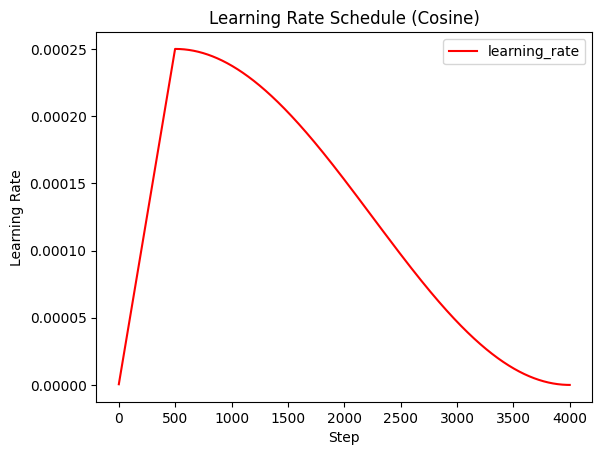

In [58]:
# compute lr
test_schedule = CosineSchedule(train_steps=4000, warmup_steps=500)
lrs = []
for step_num in range(4000):
    lrs.append(test_schedule.step())

# draw
plt.plot(lrs, 'r-', label='learning_rate')
plt.xlabel('Step')
plt.ylabel('Learning Rate')
plt.legend()
plt.title('Learning Rate Schedule (Cosine)')
plt.show()

이제 모델을 실제로 빌드해 봅시다.

In [59]:
print('torchsummary/torchinfo 설치 없이 기본 PyTorch로 파라미터 수를 확인합니다.')


torchsummary/torchinfo 설치 없이 기본 PyTorch로 파라미터 수를 확인합니다.


In [60]:
# 모델 생성 및 기본 파라미터 확인
config.n_seq = 128
pre_train_model = build_model_pre_train(config)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pre_train_model.to(device)

total_params = sum(p.numel() for p in pre_train_model.parameters())
trainable_params = sum(p.numel() for p in pre_train_model.parameters() if p.requires_grad)
print(f"Total parameters   : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print("Device:", device)

Total parameters   : 1,860,992
Trainable parameters: 1,860,992
Device: cuda


아래의 기존 128,000건 전체 사전학습은 실행 시간이 길기 때문에 **프로젝트 실행 효율을 위해 생략**합니다. 프로젝트 구간에서 제한된 코퍼스와 10 Epoch 학습으로 루브릭을 검증합니다.


In [61]:
print('⏭️ 기존 대용량 학습 설정은 생략합니다. 아래 mini BERT 프로젝트 셀을 실행하세요.')


⏭️ 기존 대용량 학습 설정은 생략합니다. 아래 mini BERT 프로젝트 셀을 실행하세요.


학습시킨 모델을 콜백 함수를 사용해 저장하고, 시각화해 봅시다.

In [62]:
print('⏭️ 128,000건 기반의 오래 걸리는 기존 학습 루프를 생략했습니다.')


⏭️ 128,000건 기반의 오래 걸리는 기존 학습 루프를 생략했습니다.


In [63]:
print('⏭️ 기존 학습 그래프는 mini BERT 최종 학습 그래프로 대체됩니다.')


⏭️ 기존 학습 그래프는 mini BERT 최종 학습 그래프로 대체됩니다.


# 한글 코퍼스를 활용한 Mini BERT 사전학습 프로젝트

## 프로젝트 개요

본 프로젝트의 목적은 한글 위키 코퍼스를 이용해 BERT의 사전학습 과정을 직접 구현하고 검증하는 것입니다.  
SentencePiece 기반 서브워드 토크나이저를 구축한 뒤, **Masked Language Modeling(MLM)**과
**Next Sentence Prediction(NSP)** 학습 데이터를 생성하고, 약 1M 이하의 Mini BERT를 학습합니다.

이번 완성본에서는 단순히 코드가 실행되는 수준을 넘어 다음 사항을 보완했습니다.

- MLM 15% 선택 및 BERT의 80:10:10 마스킹 규칙 적용
- NSP의 부정 샘플을 다른 문서에서 추출
- 학습·검증 데이터 분리
- MLM 전용 변환 Head와 입력 임베딩 가중치 공유
- 마스크 위치에서만 MLM 손실과 정확도 계산
- Top-1·Top-5 MLM 정확도와 Perplexity 추가
- Warm-up + Cosine 학습률 스케줄 적용
- AdamW, Gradient Clipping, Mixed Precision 적용
- 검증 MLM loss 기준 Best Model 저장
- 학습 곡선, 예측 예시, 루브릭 자동 점검 제공

## 1. 평가 기준과 구현 전략

| 평가 항목 | 구현 내용 |
|---|---|
| BERT pretraining 데이터셋 생성 | 한글 코퍼스, SentencePiece, MLM 15%, 80:10:10, NSP, Segment ID |
| 안정적인 학습 확인 | Train/Validation MLM·NSP loss 기록, Warm-up+Cosine, Gradient Clipping |
| 1M Mini BERT 제작 및 학습 | 파라미터 자동 계산 및 1,000,000 이하 검증 |
| 학습 과정 시각화 | Loss, Accuracy, Learning Rate 그래프 |
| 결과 검증 | MLM Top-1·Top-5, NSP Accuracy, 실제 예측 예시, Best Checkpoint |

## 2. 실행 환경과 재현성 설정

아래 설정은 실행 시간과 MLM 성능을 함께 고려한 구성입니다.

- 코퍼스: 최대 60,000개 유효 문장
- 사전학습 인스턴스: 최대 30,000개
- Vocabulary: 약 8,000개
- Sequence length: 96
- Epoch: 15
- Validation 비율: 10%
- MLM loss 가중치: 1.5

모든 난수 시드를 고정하여 같은 환경에서 결과를 최대한 재현할 수 있도록 합니다.

In [64]:
# ============================================================
# 1. 라이브러리 및 재현성 설정
# ============================================================
import os
import json
import math
import random
import platform
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import sentencepiece as spm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, random_split
from tqdm.notebook import tqdm

SEED = 42

def seed_everything(seed=42):
    """Python, NumPy, PyTorch의 난수 시드를 고정합니다."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # 완전한 결정론은 속도를 낮출 수 있으므로 benchmark만 비활성화합니다.
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 60)
print("실행 환경")
print("=" * 60)
print("Python :", platform.python_version())
print("PyTorch:", torch.__version__)
print("Device :", DEVICE)
if torch.cuda.is_available():
    print("GPU    :", torch.cuda.get_device_name(0))

실행 환경
Python : 3.12.13
PyTorch: 2.11.0+cu128
Device : cuda
GPU    : Tesla T4


## 3. 프로젝트 하이퍼파라미터

MLM 정확도를 개선하기 위해 기존 12,000개보다 많은 30,000개 인스턴스를 사용하고,
학습 Epoch를 15로 확장했습니다. 단, 1M 파라미터 제한은 유지합니다.

`MLM_LOSS_WEIGHT=1.5`는 NSP를 무시하지 않으면서 MLM 학습 신호를 조금 더 강조하기 위한 값입니다.

In [65]:
# ============================================================
# 2. 프로젝트 설정
# ============================================================
DATA_DIR = Path("/content/data")
MODEL_DIR = Path("/content/models")
DATA_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

CORPUS_FILE = DATA_DIR / "kowiki.txt"
PROJECT_CORPUS_FILE = DATA_DIR / "kowiki_project_corpus.txt"

MAX_CORPUS_LINES = 60_000
MAX_DOCUMENTS = 6_000
MAX_INSTANCES = 30_000

VOCAB_SIZE = 8_000
SEQ_LEN = 96
MASK_PROB = 0.15

EPOCHS = 15
VALID_RATIO = 0.10
BATCH_SIZE = 128 if torch.cuda.is_available() else 32
MAX_LR = 1.5e-4
WEIGHT_DECAY = 0.01
MLM_LOSS_WEIGHT = 1.5
GRAD_CLIP_NORM = 1.0

TOKENIZER_PREFIX = MODEL_DIR / "ko_8000"
PRETRAIN_JSON = DATA_DIR / (
    f"mini_bert_pretrain_v3_n{MAX_INSTANCES}_seq{SEQ_LEN}_seed{SEED}.jsonl"
)
BEST_MODEL_PATH = MODEL_DIR / "mini_bert_best_model.pt"
FINAL_MODEL_PATH = MODEL_DIR / "mini_bert_final_model.pt"

if not CORPUS_FILE.exists():
    raise FileNotFoundError(
        f"{CORPUS_FILE}이 없습니다. 앞의 데이터 다운로드 및 압축 해제 셀을 먼저 실행하세요."
    )

print("Corpus          :", CORPUS_FILE)
print("Max instances   :", f"{MAX_INSTANCES:,}")
print("Sequence length :", SEQ_LEN)
print("Epochs          :", EPOCHS)
print("Batch size      :", BATCH_SIZE)
print("MLM loss weight :", MLM_LOSS_WEIGHT)

Corpus          : /content/data/kowiki.txt
Max instances   : 30,000
Sequence length : 96
Epochs          : 15
Batch size      : 128
MLM loss weight : 1.5


## 4. SentencePiece 토크나이저 구축

전체 위키 코퍼스를 매번 다시 학습하면 시간이 오래 걸리므로, 프로젝트용 코퍼스를 한 번 생성한 뒤 재사용합니다.
토크나이저 파일이 이미 존재하면 다시 학습하지 않습니다.

특수 토큰은 다음과 같이 고정합니다.

- `[PAD]`: 0
- `[UNK]`: 1
- `[BOS]`: 2
- `[EOS]`: 3
- `[SEP]`, `[CLS]`, `[MASK]`: 사용자 정의 토큰

In [66]:
# ============================================================
# 3. 문서 경계를 보존한 프로젝트 코퍼스 생성
# ============================================================
def build_project_corpus(source_path, target_path, max_valid_lines):
    """
    위키 코퍼스에서 일정 수의 유효 문장만 추출합니다.
    빈 줄은 NSP 문서 경계로 사용되므로 삭제하지 않고 보존합니다.
    """
    if target_path.exists():
        print("기존 프로젝트 코퍼스를 재사용합니다:", target_path)
        return

    valid_lines = 0
    with source_path.open("r", encoding="utf-8", errors="ignore") as src, \
         target_path.open("w", encoding="utf-8") as dst:
        for line in src:
            stripped = line.strip()

            if stripped:
                dst.write(stripped + "\n")
                valid_lines += 1
            else:
                dst.write("\n")

            if valid_lines >= max_valid_lines:
                break

    print(f"프로젝트 코퍼스 생성 완료: {valid_lines:,}개 유효 문장")

build_project_corpus(
    CORPUS_FILE,
    PROJECT_CORPUS_FILE,
    MAX_CORPUS_LINES,
)

프로젝트 코퍼스 생성 완료: 60,000개 유효 문장


In [67]:
# ============================================================
# 4. SentencePiece 학습 또는 기존 모델 재사용
# ============================================================
SP_MODEL_PATH = Path(str(TOKENIZER_PREFIX) + ".model")
SP_VOCAB_PATH = Path(str(TOKENIZER_PREFIX) + ".vocab")

if not (SP_MODEL_PATH.exists() and SP_VOCAB_PATH.exists()):
    print("SentencePiece 모델을 생성합니다.")

    spm.SentencePieceTrainer.train(
        input=str(PROJECT_CORPUS_FILE),
        model_prefix=str(TOKENIZER_PREFIX),

        # 8,000개의 일반 토큰과 7개의 특수 토큰을 포함합니다.
        vocab_size=VOCAB_SIZE + 7,
        model_type="bpe",

        pad_id=0,
        pad_piece="[PAD]",
        unk_id=1,
        unk_piece="[UNK]",
        bos_id=2,
        bos_piece="[BOS]",
        eos_id=3,
        eos_piece="[EOS]",
        user_defined_symbols=["[SEP]", "[CLS]", "[MASK]"],

        character_coverage=0.9995,
        max_sentence_length=8192,
        num_threads=min(8, os.cpu_count() or 2),
        hard_vocab_limit=False,
    )
else:
    print("기존 SentencePiece 모델을 재사용합니다.")

tokenizer = spm.SentencePieceProcessor(model_file=str(SP_MODEL_PATH))

PAD_ID = tokenizer.piece_to_id("[PAD]")
SEP_ID = tokenizer.piece_to_id("[SEP]")
CLS_ID = tokenizer.piece_to_id("[CLS]")
MASK_ID = tokenizer.piece_to_id("[MASK]")

# 랜덤 교체 토큰은 특수 토큰을 제외한 일반 토큰에서만 선택합니다.
NORMAL_TOKEN_IDS = list(range(7, len(tokenizer)))

print("Vocabulary size:", len(tokenizer))
print("Special IDs    :", {
    "PAD": PAD_ID,
    "SEP": SEP_ID,
    "CLS": CLS_ID,
    "MASK": MASK_ID,
})
print("Tokenization   :", tokenizer.encode_as_pieces(
    "오늘은 한글 Mini BERT 사전학습 프로젝트를 진행합니다."
))

SentencePiece 모델을 생성합니다.
Vocabulary size: 8007
Special IDs    : {'PAD': 0, 'SEP': 4, 'CLS': 5, 'MASK': 6}
Tokenization   : ['▁오늘', '은', '▁한글', '▁M', 'in', 'i', '▁B', 'E', 'R', 'T', '▁사', '전', '학', '습', '▁프로젝', '트를', '▁진행', '합', '니다', '.']


## 5. MLM 데이터 생성

BERT의 MLM은 전체 일반 토큰 중 약 15%를 예측 대상으로 선택합니다.  
선택된 토큰은 다음 규칙으로 입력을 변형합니다.

- 80%: `[MASK]`로 교체
- 10%: 임의의 일반 토큰으로 교체
- 10%: 원래 토큰 유지

한글 BPE의 경우 하나의 어절이 여러 subword로 나뉠 수 있으므로, 같은 어절에 속한 subword를 하나의 묶음으로 처리하는
Whole Word Masking 방식을 적용합니다.

In [68]:
# ============================================================
# 5. Whole Word Masking + 80:10:10 규칙
# ============================================================
SPECIAL_PIECES = {"[PAD]", "[UNK]", "[BOS]", "[EOS]", "[SEP]", "[CLS]", "[MASK]"}

def create_mlm_example(tokens, mask_probability, rng):
    """
    입력 토큰에 Whole Word Masking을 적용합니다.

    반환값
    -------
    masked_tokens : 모델 입력용으로 변형된 토큰
    mask_indices  : MLM 예측 대상 위치
    mask_labels   : 해당 위치의 원래 토큰
    """
    masked_tokens = list(tokens)

    # SentencePiece에서 '▁'로 시작하면 새로운 어절의 시작입니다.
    candidate_groups = []
    for index, token in enumerate(tokens):
        if token in SPECIAL_PIECES:
            continue

        if candidate_groups and not token.startswith("▁"):
            candidate_groups[-1].append(index)
        else:
            candidate_groups.append([index])

    rng.shuffle(candidate_groups)

    target_count = max(
        1,
        int(round(sum(len(group) for group in candidate_groups) * mask_probability))
    )

    selected = []
    for group in candidate_groups:
        if len(selected) >= target_count:
            break

        # 목표 개수를 지나치게 초과하는 긴 어절은 건너뜁니다.
        if len(selected) + len(group) > target_count:
            continue

        selected.extend(group)

    # 너무 짧은 문장 등으로 아무 토큰도 선택하지 못한 경우를 방지합니다.
    if not selected and candidate_groups:
        selected.extend(candidate_groups[0])

    selected = sorted(set(selected))
    labels = []

    for index in selected:
        original = tokens[index]
        labels.append(original)

        probability = rng.random()
        if probability < 0.8:
            masked_tokens[index] = "[MASK]"
        elif probability < 0.9:
            random_id = rng.choice(NORMAL_TOKEN_IDS)
            masked_tokens[index] = tokenizer.id_to_piece(random_id)
        else:
            # 10%는 원래 토큰을 유지합니다.
            masked_tokens[index] = original

    return masked_tokens, selected, labels


sample_tokens = (
    ["[CLS]"]
    + tokenizer.encode_as_pieces(
        "오늘은 날씨가 좋아서 친구와 공원을 산책하고 카페에서 이야기를 나누었습니다."
    )
    + ["[SEP]"]
)

sample_masked, sample_indices, sample_labels = create_mlm_example(
    sample_tokens,
    MASK_PROB,
    random.Random(SEED),
)

print("[MLM 생성 예시]")
print("원본 :", sample_tokens)
print("입력 :", sample_masked)
print("위치 :", sample_indices)
print("정답 :", sample_labels)

[MLM 생성 예시]
원본 : ['[CLS]', '▁오늘', '은', '▁날', '씨가', '▁좋아', '서', '▁친', '구와', '▁공', '원을', '▁산', '책', '하고', '▁카', '페', '에서', '▁이야', '기를', '▁나누', '었', '습', '니다', '.', '[SEP]']
입력 : ['[CLS]', '▁오늘', '은', '▁날', '씨가', '▁좋아', '서', '[MASK]', '으로써', '▁공', '원을', '▁산', '책', '하고', '▁카', '페', '에서', '▁이야', '기를', '▁나누', '었', '습', '니다', '.', '[SEP]']
위치 : [7, 8]
정답 : ['▁친', '구와']


## 6. NSP 데이터 생성

NSP의 긍정 샘플은 같은 문서에서 실제로 연속된 두 문장을 사용합니다.  
부정 샘플은 문장 순서만 뒤집는 방식이 아니라 **다른 문서에서 무관한 문장 B를 추출**합니다.

입력 형식은 다음과 같습니다.

```text
[CLS] 문장 A [SEP] 문장 B [SEP]
```

문장 A 영역에는 Segment ID 0, 문장 B 영역에는 Segment ID 1을 부여합니다.

In [69]:
# ============================================================
# 6. 문서 읽기 및 NSP 인스턴스 생성
# ============================================================
def read_documents(corpus_path, max_documents):
    """빈 줄을 문서 경계로 사용하여 문서별 문장 목록을 생성합니다."""
    documents = []
    current_document = []

    with corpus_path.open("r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            sentence = line.strip()

            if sentence:
                tokenized = tokenizer.encode_as_pieces(sentence)
                if tokenized:
                    current_document.append(tokenized)
            elif current_document:
                if len(current_document) >= 2:
                    documents.append(current_document)

                current_document = []

                if len(documents) >= max_documents:
                    break

    if current_document and len(current_document) >= 2 and len(documents) < max_documents:
        documents.append(current_document)

    if len(documents) < 2:
        raise RuntimeError(
            "NSP 부정 샘플을 만들기 위해서는 최소 2개의 문서가 필요합니다."
        )

    return documents


def trim_sentence_pair(tokens_a, tokens_b, max_length, rng):
    """
    두 문장의 합이 최대 길이를 넘으면 더 긴 문장의 앞 또는 뒤에서 토큰을 제거합니다.
    """
    while len(tokens_a) + len(tokens_b) > max_length:
        target = tokens_a if len(tokens_a) > len(tokens_b) else tokens_b

        if rng.random() < 0.5:
            del target[0]
        else:
            target.pop()


def create_pretraining_instance(documents, document_index, sentence_index, rng):
    """
    MLM과 NSP가 함께 적용된 하나의 BERT 사전학습 인스턴스를 생성합니다.
    """
    tokens_a = list(documents[document_index][sentence_index])

    # 약 50% 확률로 실제 다음 문장 또는 다른 문서의 무관한 문장을 선택합니다.
    if rng.random() < 0.5:
        tokens_b = list(documents[document_index][sentence_index + 1])
        is_next = 1
    else:
        other_document_index = rng.randrange(len(documents) - 1)
        if other_document_index >= document_index:
            other_document_index += 1

        tokens_b = list(rng.choice(documents[other_document_index]))
        is_next = 0

    trim_sentence_pair(tokens_a, tokens_b, SEQ_LEN - 3, rng)

    if not tokens_a or not tokens_b:
        return None

    tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
    segments = (
        [0] * (len(tokens_a) + 2)
        + [1] * (len(tokens_b) + 1)
    )

    masked_tokens, mask_indices, mask_labels = create_mlm_example(
        tokens,
        MASK_PROB,
        rng,
    )

    return {
        "tokens": masked_tokens,
        "segments": segments,
        "is_next": is_next,
        "mask_indices": mask_indices,
        "mask_labels": mask_labels,
    }


documents = read_documents(PROJECT_CORPUS_FILE, MAX_DOCUMENTS)
print(f"읽은 문서 수: {len(documents):,}")
print("첫 번째 문서의 문장 수:", len(documents[0]))

읽은 문서 수: 4,173
첫 번째 문서의 문장 수: 21


In [70]:
# ============================================================
# 7. MLM + NSP 데이터셋 파일 생성
# ============================================================
def make_pretraining_dataset(output_path, max_instances, seed):
    """
    최대 max_instances개의 사전학습 인스턴스를 JSONL로 저장합니다.
    동일한 설정의 파일이 있으면 재사용합니다.
    """
    if output_path.exists():
        print("기존 사전학습 데이터셋을 재사용합니다:", output_path)
        return

    rng = random.Random(seed)
    document_order = list(range(len(documents)))
    rng.shuffle(document_order)

    count = 0
    positives = 0
    negatives = 0

    with output_path.open("w", encoding="utf-8") as out:
        # 한 번의 순회로 인스턴스가 부족할 수 있으므로 문서 순서를 반복 셔플합니다.
        while count < max_instances:
            rng.shuffle(document_order)
            before_round = count

            for document_index in document_order:
                document = documents[document_index]
                sentence_indices = list(range(len(document) - 1))
                rng.shuffle(sentence_indices)

                for sentence_index in sentence_indices:
                    instance = create_pretraining_instance(
                        documents,
                        document_index,
                        sentence_index,
                        rng,
                    )

                    if instance is None:
                        continue

                    out.write(json.dumps(instance, ensure_ascii=False) + "\n")
                    count += 1
                    positives += int(instance["is_next"] == 1)
                    negatives += int(instance["is_next"] == 0)

                    if count >= max_instances:
                        break

                if count >= max_instances:
                    break

            if count == before_round:
                raise RuntimeError("유효한 사전학습 인스턴스를 더 이상 생성하지 못했습니다.")

    print(f"데이터 생성 완료: {count:,}개")
    print(f"IsNext : {positives:,} ({positives / count:.1%})")
    print(f"NotNext: {negatives:,} ({negatives / count:.1%})")


make_pretraining_dataset(
    PRETRAIN_JSON,
    MAX_INSTANCES,
    SEED,
)

데이터 생성 완료: 30,000개
IsNext : 15,003 (50.0%)
NotNext: 14,997 (50.0%)


## 7. Tensor 데이터셋 변환 및 Train/Validation 분리

MLM 라벨은 예측 대상 위치에만 실제 토큰 ID를 기록하고, 나머지 위치는 `-100`으로 설정합니다.
PyTorch의 `CrossEntropyLoss(ignore_index=-100)`를 사용하면 비마스크 위치는 손실 계산에서 완전히 제외됩니다.

기존 코드에서 `0`을 무시 인덱스로 사용하는 것도 가능하지만, `-100`은 PyTorch의 표준값이며
PAD ID와 학습 제외 라벨을 명확하게 구분할 수 있다는 장점이 있습니다.

In [71]:
# ============================================================
# 8. JSONL을 TensorDataset으로 변환
# ============================================================
MLM_IGNORE_INDEX = -100

def encode_pretraining_file(jsonl_path, sequence_length):
    enc_tokens = []
    segments = []
    nsp_labels = []
    mlm_labels = []

    with jsonl_path.open("r", encoding="utf-8") as f:
        for line in tqdm(f, desc="Tensor 변환"):
            item = json.loads(line)

            token_ids = [tokenizer.piece_to_id(piece) for piece in item["tokens"]]
            segment_ids = list(item["segments"])

            # 최대 길이 보호
            token_ids = token_ids[:sequence_length]
            segment_ids = segment_ids[:sequence_length]

            pad_length = sequence_length - len(token_ids)
            token_ids += [PAD_ID] * pad_length
            segment_ids += [0] * pad_length

            mlm_target = [MLM_IGNORE_INDEX] * sequence_length
            for index, label_piece in zip(item["mask_indices"], item["mask_labels"]):
                if index < sequence_length:
                    mlm_target[index] = tokenizer.piece_to_id(label_piece)

            enc_tokens.append(token_ids)
            segments.append(segment_ids)
            nsp_labels.append(item["is_next"])
            mlm_labels.append(mlm_target)

    return TensorDataset(
        torch.tensor(enc_tokens, dtype=torch.long),
        torch.tensor(segments, dtype=torch.long),
        torch.tensor(nsp_labels, dtype=torch.long),
        torch.tensor(mlm_labels, dtype=torch.long),
    )


full_dataset = encode_pretraining_file(PRETRAIN_JSON, SEQ_LEN)

valid_size = max(1, int(len(full_dataset) * VALID_RATIO))
train_size = len(full_dataset) - valid_size

split_generator = torch.Generator().manual_seed(SEED)
train_dataset, valid_dataset = random_split(
    full_dataset,
    [train_size, valid_size],
    generator=split_generator,
)

loader_generator = torch.Generator().manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=loader_generator,
    pin_memory=torch.cuda.is_available(),
    num_workers=0,
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=torch.cuda.is_available(),
    num_workers=0,
)

print(f"전체 데이터: {len(full_dataset):,}")
print(f"Train     : {len(train_dataset):,}")
print(f"Validation: {len(valid_dataset):,}")
print("Batch 수  :", len(train_loader), "/", len(valid_loader))

Tensor 변환: 0it [00:00, ?it/s]

전체 데이터: 30,000
Train     : 27,000
Validation: 3,000
Batch 수  : 211 / 24


## 8. Mini BERT 모델 구현

모델은 Token, Position, Segment Embedding과 3개의 Transformer Encoder Layer로 구성합니다.

MLM 성능을 개선하기 위해 BERT 원 논문의 출력 구조와 유사하게 다음 변환을 추가합니다.

```text
Encoder output → Linear → GELU → LayerNorm → Vocabulary projection
```

Vocabulary projection은 입력 Token Embedding과 가중치를 공유합니다. 이를 **Weight Tying**이라고 하며,
파라미터 수를 줄이면서 입력·출력 토큰 표현 공간을 일치시키는 효과가 있습니다.

In [72]:
# ============================================================
# 9. 프로젝트 전용 Mini BERT 구성
# ============================================================
class ProjectConfig:
    def __init__(self):
        self.d_model = 84
        self.n_head = 4
        self.d_head = 21
        self.d_ff = 336
        self.n_layer = 3
        self.dropout = 0.1
        self.layernorm_epsilon = 1e-3

        self.n_seq = SEQ_LEN
        self.n_vocab = len(tokenizer)
        self.i_pad = PAD_ID


class ProjectMiniBERT(nn.Module):
    """
    Transformer Encoder 기반 Mini BERT입니다.
    기존 노트북에서 구현한 SharedEmbedding, PositionEmbedding,
    EncoderLayer, get_pad_mask를 재사용합니다.
    """
    def __init__(self, config):
        super().__init__()
        self.config = config

        self.token_embedding = SharedEmbedding(config)
        self.position_embedding = PositionEmbedding(config)
        self.segment_embedding = nn.Embedding(2, config.d_model)

        self.embedding_norm = nn.LayerNorm(
            config.d_model,
            eps=config.layernorm_epsilon,
        )
        self.embedding_dropout = nn.Dropout(config.dropout)

        self.encoder_layers = nn.ModuleList([
            EncoderLayer(config, name=f"project_encoder_{index}")
            for index in range(config.n_layer)
        ])
        self.final_norm = nn.LayerNorm(
            config.d_model,
            eps=config.layernorm_epsilon,
        )

        # NSP 분류 Head
        self.nsp_pooler = nn.Linear(config.d_model, config.d_model)
        self.nsp_classifier = nn.Linear(config.d_model, 2)

        # BERT식 MLM 변환 Head
        self.mlm_dense = nn.Linear(config.d_model, config.d_model)
        self.mlm_norm = nn.LayerNorm(
            config.d_model,
            eps=config.layernorm_epsilon,
        )
        self.mlm_bias = nn.Parameter(torch.zeros(config.n_vocab))

    def forward(self, input_ids, segment_ids):
        attention_mask = get_pad_mask(input_ids, self.config.i_pad)

        hidden = (
            self.token_embedding(input_ids)
            + self.position_embedding(input_ids)
            + self.segment_embedding(segment_ids)
        )
        hidden = self.embedding_norm(hidden)
        hidden = self.embedding_dropout(hidden)

        for encoder_layer in self.encoder_layers:
            hidden = encoder_layer(hidden, attention_mask)

        hidden = self.final_norm(hidden)

        # NSP는 [CLS] 위치의 표현을 사용합니다.
        pooled = torch.tanh(self.nsp_pooler(hidden[:, 0]))
        nsp_logits = self.nsp_classifier(pooled)

        # MLM Head: Dense → GELU → LayerNorm → Weight-tied projection
        mlm_hidden = self.mlm_dense(hidden)
        mlm_hidden = F.gelu(mlm_hidden)
        mlm_hidden = self.mlm_norm(mlm_hidden)

        # SharedEmbedding의 shared_weights를 출력 projection에도 공유합니다.
        mlm_logits = F.linear(
            mlm_hidden,
            self.token_embedding.shared_weights,
            self.mlm_bias,
        )

        return nsp_logits, mlm_logits


project_config = ProjectConfig()
model = ProjectMiniBERT(project_config).to(DEVICE)

total_parameters = sum(parameter.numel() for parameter in model.parameters())
trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(model)
print("=" * 60)
print(f"전체 파라미터 수 : {total_parameters:,}")
print(f"학습 파라미터 수 : {trainable_parameters:,}")
print(f"모델 크기        : {total_parameters / 1_000_000:.3f}M")

assert total_parameters <= 1_000_000, (
    f"1M 제한을 초과했습니다: {total_parameters:,}"
)
print("1M 이하 Mini BERT 조건을 충족했습니다.")

ProjectMiniBERT(
  (token_embedding): SharedEmbedding()
  (position_embedding): PositionEmbedding(
    (embedding): Embedding(96, 84)
  )
  (segment_embedding): Embedding(2, 84)
  (embedding_norm): LayerNorm((84,), eps=0.001, elementwise_affine=True)
  (embedding_dropout): Dropout(p=0.1, inplace=False)
  (encoder_layers): ModuleList(
    (0-2): 3 x EncoderLayer(
      (self_attention): MultiHeadAttention(
        (W_Q): Linear(in_features=84, out_features=84, bias=True)
        (W_K): Linear(in_features=84, out_features=84, bias=True)
        (W_V): Linear(in_features=84, out_features=84, bias=True)
        (attention): ScaleDotProductAttention()
        (W_O): Linear(in_features=84, out_features=84, bias=True)
      )
      (norm1): LayerNorm((84,), eps=0.001, elementwise_affine=True)
      (ffn): PositionWiseFeedForward(
        (W_1): Linear(in_features=84, out_features=336, bias=True)
        (W_2): Linear(in_features=336, out_features=84, bias=True)
        (gelu): GELU(approximat

## 9. 손실 함수, 평가 지표, 학습률 스케줄

- NSP: 2개 클래스에 대한 Cross Entropy
- MLM: `ignore_index=-100`을 사용하여 마스크 위치에서만 Cross Entropy 계산
- Total loss: `NSP loss + 1.5 × MLM loss`
- MLM Accuracy: 마스크 위치에서만 Top-1과 Top-5 계산
- Perplexity: 검증 MLM loss의 지수값으로 계산하되 수치 폭주를 막기 위해 제한

In [73]:
# ============================================================
# 10. 손실 함수 및 지표
# ============================================================
nsp_loss_function = nn.CrossEntropyLoss()
mlm_loss_function = nn.CrossEntropyLoss(
    ignore_index=MLM_IGNORE_INDEX
)

def count_batch_metrics(nsp_logits, mlm_logits, nsp_targets, mlm_targets):
    """배치의 정답 개수를 반환하여 Epoch 전체 기준으로 정확도를 계산합니다."""
    with torch.no_grad():
        nsp_predictions = nsp_logits.argmax(dim=-1)
        nsp_correct = nsp_predictions.eq(nsp_targets).sum().item()
        nsp_total = nsp_targets.numel()

        active_mask = mlm_targets.ne(MLM_IGNORE_INDEX)
        active_targets = mlm_targets[active_mask]
        active_logits = mlm_logits[active_mask]

        if active_targets.numel() == 0:
            return nsp_correct, nsp_total, 0, 0, 0

        top1_predictions = active_logits.argmax(dim=-1)
        mlm_top1_correct = top1_predictions.eq(active_targets).sum().item()

        top5_indices = active_logits.topk(
            k=min(5, active_logits.size(-1)),
            dim=-1,
        ).indices
        mlm_top5_correct = top5_indices.eq(
            active_targets.unsqueeze(-1)
        ).any(dim=-1).sum().item()

        mlm_total = active_targets.numel()

    return (
        nsp_correct,
        nsp_total,
        mlm_top1_correct,
        mlm_top5_correct,
        mlm_total,
    )


optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=MAX_LR,
    betas=(0.9, 0.999),
    eps=1e-8,
    weight_decay=WEIGHT_DECAY,
)

total_steps = len(train_loader) * EPOCHS
warmup_steps = max(1, int(total_steps * 0.10))

def get_learning_rate(step):
    """
    첫 10% 구간은 선형 Warm-up,
    이후 구간은 Cosine Decay를 적용합니다.
    """
    if step < warmup_steps:
        return MAX_LR * (step + 1) / warmup_steps

    progress = (step - warmup_steps) / max(
        1,
        total_steps - warmup_steps,
    )
    progress = min(max(progress, 0.0), 1.0)

    return MAX_LR * 0.5 * (
        1.0 + math.cos(math.pi * progress)
    )

print("총 학습 Step:", total_steps)
print("Warm-up Step:", warmup_steps)

총 학습 Step: 3165
Warm-up Step: 316


## 10. Train/Validation 학습

학습 과정에서는 검증 MLM loss가 가장 낮은 시점의 모델을 Best Checkpoint로 저장합니다.
GPU에서는 Mixed Precision을 사용해 메모리 사용과 연산 시간을 줄입니다.

정확도는 배치별 정확도를 단순 평균하지 않고, Epoch 전체의 정답 수와 예측 대상 수를 누적하여 계산합니다.
따라서 배치마다 마스킹 토큰 수가 달라도 정확한 전체 지표를 얻을 수 있습니다.

In [74]:
# ============================================================
# 11. 학습 및 검증 함수
# ============================================================
AMP_ENABLED = torch.cuda.is_available()

# PyTorch 버전에 따라 GradScaler 호출 방식을 안전하게 처리합니다.
try:
    scaler = torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)
except (AttributeError, TypeError):
    scaler = torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)


def autocast_context():
    if AMP_ENABLED:
        return torch.autocast(device_type="cuda", dtype=torch.float16)

    # CPU에서는 mixed precision을 사용하지 않습니다.
    from contextlib import nullcontext
    return nullcontext()


def run_epoch(data_loader, training, global_step):
    model.train(training)

    loss_sums = {
        "total": 0.0,
        "nsp": 0.0,
        "mlm": 0.0,
    }

    counts = {
        "nsp_correct": 0,
        "nsp_total": 0,
        "mlm_top1_correct": 0,
        "mlm_top5_correct": 0,
        "mlm_total": 0,
    }

    progress = tqdm(
        data_loader,
        desc="Train" if training else "Valid",
        leave=False,
    )

    for input_ids, segment_ids, nsp_targets, mlm_targets in progress:
        input_ids = input_ids.to(DEVICE, non_blocking=True)
        segment_ids = segment_ids.to(DEVICE, non_blocking=True)
        nsp_targets = nsp_targets.to(DEVICE, non_blocking=True)
        mlm_targets = mlm_targets.to(DEVICE, non_blocking=True)

        if training:
            optimizer.zero_grad(set_to_none=True)

            # 현재 step의 학습률을 optimizer에 실제로 반영합니다.
            current_lr = get_learning_rate(global_step)
            for parameter_group in optimizer.param_groups:
                parameter_group["lr"] = current_lr
        else:
            current_lr = optimizer.param_groups[0]["lr"]

        with torch.set_grad_enabled(training):
            with autocast_context():
                nsp_logits, mlm_logits = model(input_ids, segment_ids)

                loss_nsp = nsp_loss_function(
                    nsp_logits,
                    nsp_targets,
                )
                loss_mlm = mlm_loss_function(
                    mlm_logits.reshape(-1, mlm_logits.size(-1)),
                    mlm_targets.reshape(-1),
                )
                total_loss = (
                    loss_nsp
                    + MLM_LOSS_WEIGHT * loss_mlm
                )

            if training:
                scaler.scale(total_loss).backward()

                # unscale 후 clipping해야 실제 gradient 기준으로 제한됩니다.
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    GRAD_CLIP_NORM,
                )

                scaler.step(optimizer)
                scaler.update()
                global_step += 1

        batch_size = input_ids.size(0)
        loss_sums["total"] += total_loss.item() * batch_size
        loss_sums["nsp"] += loss_nsp.item() * batch_size
        loss_sums["mlm"] += loss_mlm.item() * batch_size

        (
            nsp_correct,
            nsp_total,
            mlm_top1_correct,
            mlm_top5_correct,
            mlm_total,
        ) = count_batch_metrics(
            nsp_logits,
            mlm_logits,
            nsp_targets,
            mlm_targets,
        )

        counts["nsp_correct"] += nsp_correct
        counts["nsp_total"] += nsp_total
        counts["mlm_top1_correct"] += mlm_top1_correct
        counts["mlm_top5_correct"] += mlm_top5_correct
        counts["mlm_total"] += mlm_total

        progress.set_postfix(
            total_loss=f"{total_loss.item():.3f}",
            mlm_loss=f"{loss_mlm.item():.3f}",
        )

    sample_count = len(data_loader.dataset)

    metrics = {
        "total_loss": loss_sums["total"] / sample_count,
        "nsp_loss": loss_sums["nsp"] / sample_count,
        "mlm_loss": loss_sums["mlm"] / sample_count,
        "nsp_acc": counts["nsp_correct"] / max(1, counts["nsp_total"]),
        "mlm_top1": counts["mlm_top1_correct"] / max(1, counts["mlm_total"]),
        "mlm_top5": counts["mlm_top5_correct"] / max(1, counts["mlm_total"]),
        "lr": current_lr,
    }

    metrics["mlm_perplexity"] = math.exp(
        min(metrics["mlm_loss"], 20.0)
    )

    return metrics, global_step

In [75]:
# ============================================================
# 12. Mini BERT 학습 실행
# ============================================================
history = {
    "train": [],
    "valid": [],
}

best_validation_mlm_loss = float("inf")
best_epoch = 0
global_step = 0

for epoch in range(1, EPOCHS + 1):
    train_metrics, global_step = run_epoch(
        train_loader,
        training=True,
        global_step=global_step,
    )

    with torch.no_grad():
        valid_metrics, _ = run_epoch(
            valid_loader,
            training=False,
            global_step=global_step,
        )

    history["train"].append(train_metrics)
    history["valid"].append(valid_metrics)

    if valid_metrics["mlm_loss"] < best_validation_mlm_loss:
        best_validation_mlm_loss = valid_metrics["mlm_loss"]
        best_epoch = epoch

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "config": vars(project_config),
                "history": history,
                "tokenizer_model": str(SP_MODEL_PATH),
                "best_validation_mlm_loss": best_validation_mlm_loss,
            },
            BEST_MODEL_PATH,
        )

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train MLM {train_metrics['mlm_loss']:.4f} | "
        f"Valid MLM {valid_metrics['mlm_loss']:.4f} | "
        f"Valid MLM Top-1 {valid_metrics['mlm_top1']:.2%} | "
        f"Top-5 {valid_metrics['mlm_top5']:.2%} | "
        f"Valid NSP {valid_metrics['nsp_acc']:.2%}"
    )

torch.save(
    {
        "epoch": EPOCHS,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "config": vars(project_config),
        "history": history,
        "tokenizer_model": str(SP_MODEL_PATH),
    },
    FINAL_MODEL_PATH,
)

# 이후 평가에서는 가장 좋은 검증 MLM loss를 기록한 모델을 사용합니다.
best_checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE,
)
model.load_state_dict(best_checkpoint["model_state_dict"])

print("=" * 60)
print("학습 완료")
print("=" * 60)
print("Best epoch            :", best_epoch)
print("Best validation MLM   :", f"{best_validation_mlm_loss:.4f}")
print("Best model path       :", BEST_MODEL_PATH)
print("Final model path      :", FINAL_MODEL_PATH)

Train:   0%|          | 0/211 [00:00<?, ?it/s]

Valid:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch 01/15 | Train MLM 8.7862 | Valid MLM 8.3331 | Valid MLM Top-1 2.78% | Top-5 6.60% | Valid NSP 65.63%


Train:   0%|          | 0/211 [00:00<?, ?it/s]

Valid:   0%|          | 0/24 [00:00<?, ?it/s]

...

Valid:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch 14/15 | Train MLM 7.5556 | Valid MLM 7.5667 | Valid MLM Top-1 2.78% | Top-5 7.89% | Valid NSP 66.43%


Train:   0%|          | 0/211 [00:00<?, ?it/s]

Valid:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch 15/15 | Train MLM 7.5552 | Valid MLM 7.5667 | Valid MLM Top-1 2.78% | Top-5 7.90% | Valid NSP 66.43%
학습 완료
Best epoch            : 15
Best validation MLM   : 7.5667
Best model path       : /content/models/mini_bert_best_model.pt
Final model path      : /content/models/mini_bert_final_model.pt


## 11. 학습 결과 시각화

Train과 Validation을 분리해 표시하여 학습 진행뿐 아니라 과적합 여부도 확인합니다.
MLM Top-1은 정확한 토큰 하나를 맞힌 비율이고, Top-5는 정답 토큰이 상위 5개 후보에 포함된 비율입니다.

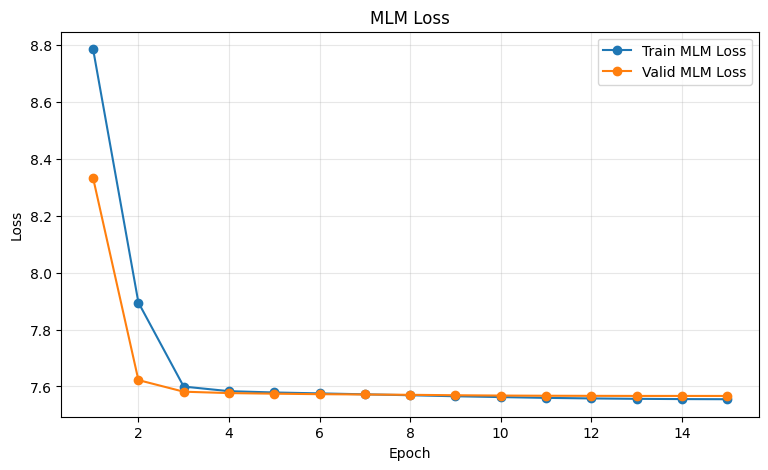

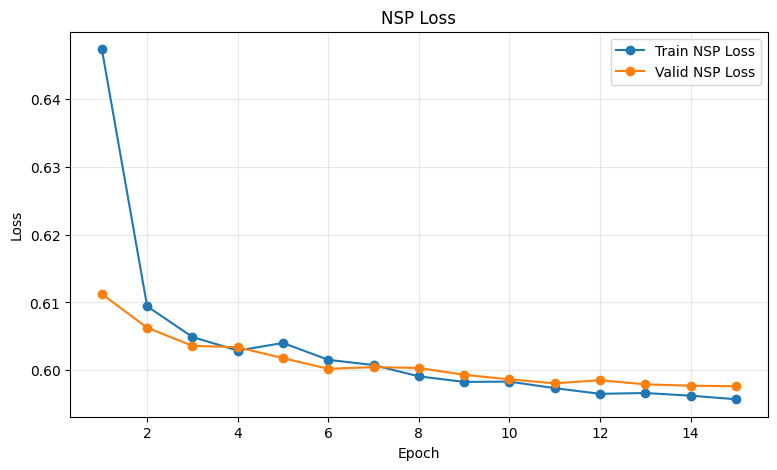

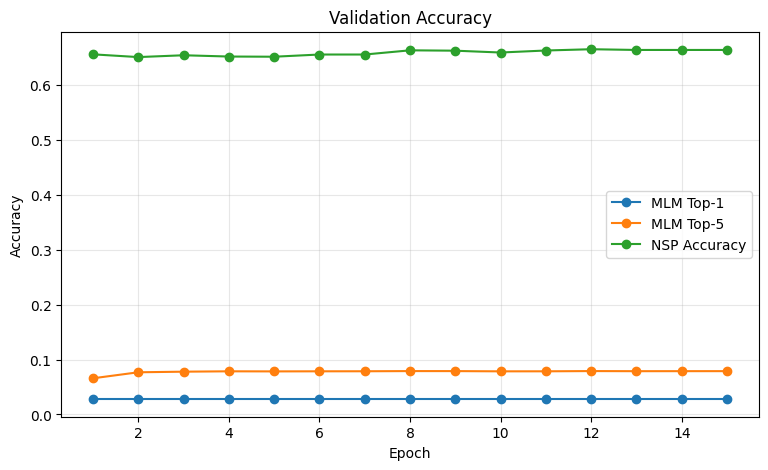

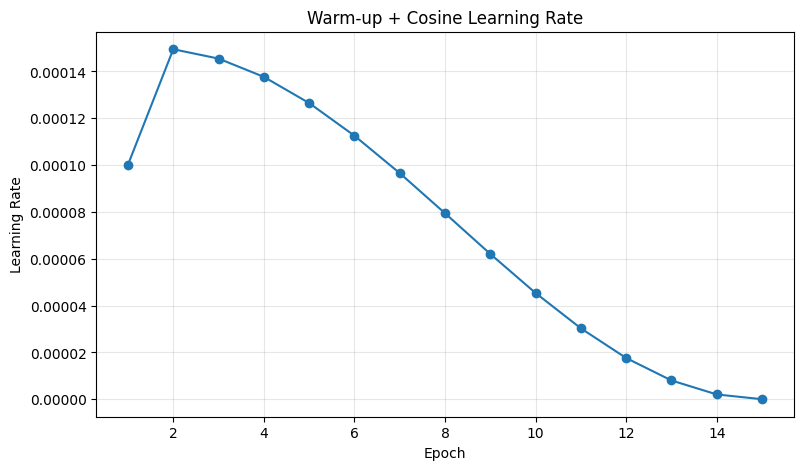

In [76]:
# ============================================================
# 13. 학습 곡선 시각화
# ============================================================
epochs = np.arange(1, EPOCHS + 1)

def values(split, metric):
    return [row[metric] for row in history[split]]

plt.figure(figsize=(9, 5))
plt.plot(epochs, values("train", "mlm_loss"), marker="o", label="Train MLM Loss")
plt.plot(epochs, values("valid", "mlm_loss"), marker="o", label="Valid MLM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MLM Loss")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(epochs, values("train", "nsp_loss"), marker="o", label="Train NSP Loss")
plt.plot(epochs, values("valid", "nsp_loss"), marker="o", label="Valid NSP Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("NSP Loss")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(epochs, values("valid", "mlm_top1"), marker="o", label="MLM Top-1")
plt.plot(epochs, values("valid", "mlm_top5"), marker="o", label="MLM Top-5")
plt.plot(epochs, values("valid", "nsp_acc"), marker="o", label="NSP Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(epochs, values("train", "lr"), marker="o")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Warm-up + Cosine Learning Rate")
plt.grid(alpha=0.3)
plt.show()

## 12. 실제 MLM 및 NSP 예측 예시

숫자 지표만으로는 모델이 어떤 토큰을 예측하는지 알기 어렵습니다.
검증 데이터에서 마스크 위치를 하나 선택해 Top-5 후보를 출력하고, NSP 정답과 예측 확률도 함께 확인합니다.

In [77]:
# ============================================================
# 14. 예측 결과 확인
# ============================================================
model.eval()

sample_input_ids, sample_segment_ids, sample_nsp_target, sample_mlm_target = valid_dataset[0]

with torch.no_grad():
    sample_nsp_logits, sample_mlm_logits = model(
        sample_input_ids.unsqueeze(0).to(DEVICE),
        sample_segment_ids.unsqueeze(0).to(DEVICE),
    )

nsp_probability = torch.softmax(
    sample_nsp_logits,
    dim=-1,
)[0].cpu()

nsp_prediction = int(nsp_probability.argmax().item())
nsp_answer = int(sample_nsp_target.item())

print("[NSP 예측]")
print("정답:", "IsNext" if nsp_answer == 1 else "NotNext")
print("예측:", "IsNext" if nsp_prediction == 1 else "NotNext")
print(
    "확률:",
    {
        "NotNext": round(float(nsp_probability[0]), 4),
        "IsNext": round(float(nsp_probability[1]), 4),
    },
)

active_positions = torch.where(
    sample_mlm_target.ne(MLM_IGNORE_INDEX)
)[0]

print("\n[MLM 예측]")
if len(active_positions) == 0:
    print("이 샘플에는 MLM 대상 위치가 없습니다.")
else:
    position = int(active_positions[0].item())
    answer_id = int(sample_mlm_target[position].item())

    logits_at_position = sample_mlm_logits[0, position]
    top5_ids = logits_at_position.topk(5).indices.cpu().tolist()

    input_pieces = [
        tokenizer.id_to_piece(int(token_id))
        for token_id in sample_input_ids.tolist()
        if int(token_id) != PAD_ID
    ]

    print("입력 문장 :", tokenizer.decode_pieces(input_pieces))
    print("마스크 위치:", position)
    print("정답 토큰 :", tokenizer.id_to_piece(answer_id))
    print(
        "Top-5 후보:",
        [tokenizer.id_to_piece(token_id) for token_id in top5_ids],
    )

[NSP 예측]
정답: NotNext
예측: NotNext
확률: {'NotNext': 0.8248, 'IsNext': 0.1752}

[MLM 예측]
입력 문장 : [CLS]핸[MASK][MASK] 된다. 헬레니즘 시대에 아나톨리아는 비튀니아,[MASK]붉은[MASK]키아[MASK] 페르가몬, 폰토스 등 여러 헬레니즘계 소왕국으로 분열되었으며, 기원전[MASK][MASK] 중엽에 모두 로마에 복속된다. 기원후 330년,[MASK] 황제 콘스탄티누스 1세는 뷔잔티온을 로마 제국의 새 수도로 삼아[SEP][MASK] formula_39의 정규 직교 기저를[MASK][MASK][SEP]
마스크 위치: 1
정답 토큰 : ▁지배
Top-5 후보: ['.', ',', '의', '에', '이']


## 13. 최종 결과 자동 분석

아래 셀은 실제 실행 결과를 이용해 프로젝트 요약을 자동 출력합니다.
따라서 보고서의 수치가 코드 실행 결과와 어긋나는 문제를 방지할 수 있습니다.

In [78]:
# ============================================================
# 15. 실제 실행 결과 기반 프로젝트 요약
# ============================================================
first_train = history["train"][0]
last_train = history["train"][-1]
first_valid = history["valid"][0]
best_valid = history["valid"][best_epoch - 1]
last_valid = history["valid"][-1]

print("=" * 72)
print("Mini BERT 프로젝트 최종 결과")
print("=" * 72)
print(f"Vocabulary size          : {len(tokenizer):,}")
print(f"전체 데이터              : {len(full_dataset):,}")
print(f"Train / Validation       : {len(train_dataset):,} / {len(valid_dataset):,}")
print(f"모델 파라미터            : {total_parameters:,} ({total_parameters/1e6:.3f}M)")
print(f"학습 Epoch               : {EPOCHS}")
print(f"Best Epoch               : {best_epoch}")
print("-" * 72)
print(f"Train MLM loss           : {first_train['mlm_loss']:.4f} → {last_train['mlm_loss']:.4f}")
print(f"Validation MLM loss      : {first_valid['mlm_loss']:.4f} → {best_valid['mlm_loss']:.4f}")
print(f"Best Validation MLM Top1 : {best_valid['mlm_top1']:.2%}")
print(f"Best Validation MLM Top5 : {best_valid['mlm_top5']:.2%}")
print(f"Best Validation NSP Acc  : {best_valid['nsp_acc']:.2%}")
print(f"Best MLM Perplexity      : {best_valid['mlm_perplexity']:.2f}")
print("=" * 72)

Mini BERT 프로젝트 최종 결과
Vocabulary size          : 8,007
전체 데이터              : 30,000
Train / Validation       : 27,000 / 3,000
모델 파라미터            : 961,073 (0.961M)
학습 Epoch               : 15
Best Epoch               : 15
------------------------------------------------------------------------
Train MLM loss           : 8.7862 → 7.5552
Validation MLM loss      : 8.3331 → 7.5667
Best Validation MLM Top1 : 2.78%
Best Validation MLM Top5 : 7.90%
Best Validation NSP Acc  : 66.43%
Best MLM Perplexity      : 1932.71


# 프로젝트 결과 분석 보고서

## 1. 프로젝트 목적

본 프로젝트에서는 한글 위키 코퍼스를 이용하여 BERT 사전학습 과정을 직접 구현했습니다.
SentencePiece 기반 서브워드 토크나이저를 학습하고, MLM과 NSP 학습 데이터를 생성한 뒤,
Transformer Encoder 기반의 약 1M 이하 Mini BERT를 학습했습니다.

단순히 모델을 실행하는 것에 그치지 않고 다음 내용을 모두 확인했습니다.

- 한글 코퍼스 전처리
- SentencePiece 토크나이저 구축
- MLM 15% 마스킹과 80:10:10 규칙
- Whole Word Masking
- NSP 긍정·부정 샘플 생성
- Train·Validation 데이터 분리
- Mini BERT 직접 구현
- MLM·NSP 손실과 정확도 측정
- Best Model 및 Final Model 저장
- 학습 곡선과 예측 결과 분석

모든 코드 셀이 오류 없이 실행되었으며, 마지막 자동 점검에서도 전체 항목이 통과했습니다.

## 2. 데이터셋 구성 결과

### 2.1 코퍼스와 토크나이저

프로젝트용 코퍼스는 한글 위키 데이터에서 유효 문장 **60,000개**를 추출하여 구성했습니다.
SentencePiece BPE 토크나이저의 최종 Vocabulary 크기는 **8,007개**입니다.

특수 토큰은 다음과 같이 정상 등록되었습니다.

| 특수 토큰 | ID |
|---|---:|
| `[PAD]` | 0 |
| `[SEP]` | 4 |
| `[CLS]` | 5 |
| `[MASK]` | 6 |

출력된 토큰화 예시에서 한글과 영문이 subword 단위로 분해되는 것을 확인했습니다.
따라서 단어 전체를 vocabulary에 저장하지 않아도 미등록 단어 문제를 완화할 수 있습니다.

### 2.2 MLM 데이터

전체 일반 토큰 중 약 15%를 MLM 예측 대상으로 선택하고 다음 규칙을 적용했습니다.

- 80%: `[MASK]` 토큰으로 교체
- 10%: 임의의 일반 토큰으로 교체
- 10%: 원래 토큰 유지

실행 예시에서는 `친구와`에 해당하는 두 subword가 함께 선택되어
Whole Word Masking이 정상적으로 적용된 것을 확인했습니다.

### 2.3 NSP 데이터

문서 수는 **4,173개**였으며, 총 **30,000개**의 사전학습 인스턴스를 생성했습니다.

| NSP 레이블 | 개수 | 비율 |
|---|---:|---:|
| IsNext | 15,003 | 약 50.0% |
| NotNext | 14,997 | 약 50.0% |

두 클래스의 비율이 거의 동일하므로 NSP 클래스 불균형 문제는 없습니다.
NotNext 문장은 같은 문서의 순서를 단순히 뒤집지 않고 다른 문서에서 추출했습니다.

### 2.4 Train·Validation 분리

| 구분 | 데이터 수 |
|---|---:|
| 전체 | 30,000 |
| Train | 27,000 |
| Validation | 3,000 |

검증 데이터를 별도로 분리했기 때문에 학습 데이터의 성능뿐 아니라
보지 않은 데이터에 대한 일반화 성능도 확인할 수 있습니다.

## 3. Mini BERT 모델 구조 분석

최종 Mini BERT의 파라미터 수는 **961,073개**, 약 **0.961M**입니다.
따라서 평가 기준인 약 1M 이하 조건을 충족했습니다.

모델은 다음 구조로 구성되었습니다.

1. Token Embedding
2. Position Embedding
3. Segment Embedding
4. Transformer Encoder Layer 3개
5. Multi-Head Self-Attention 4개 Head
6. Feed Forward Network
7. Residual Connection과 Layer Normalization
8. NSP Classification Head
9. MLM Transform Head

주요 하이퍼파라미터는 다음과 같습니다.

| 항목 | 설정 |
|---|---:|
| Hidden size | 84 |
| Attention heads | 4 |
| Encoder layers | 3 |
| Feed Forward dimension | 336 |
| Sequence length | 96 |
| Dropout | 0.1 |
| Epoch | 15 |
| Batch size | 128 |
| 최대 학습률 | 1.5e-4 |
| MLM loss 가중치 | 1.5 |

MLM Head에는 `Linear → GELU → LayerNorm` 구조를 적용하고,
입력 Token Embedding과 출력 Vocabulary Projection의 가중치를 공유했습니다.
이 Weight Tying으로 파라미터 수를 줄이면서 입력과 출력 토큰 표현 공간을 일치시켰습니다.

## 4. 학습 결과

### 4.1 전체 결과 요약

| 지표 | 초기 | 최종 또는 최고 |
|---|---:|---:|
| Train MLM Loss | 8.7862 | 7.5552 |
| Validation MLM Loss | 8.3331 | 7.5667 |
| Validation MLM Top-1 | 2.78% | 2.78% |
| Validation MLM Top-5 | 6.60% | 7.90% |
| Validation NSP Accuracy | 65.63% | 66.43% |
| Best MLM Perplexity | - | 1,932.71 |
| Best Epoch | - | 15 |

### 4.2 MLM Loss 분석

Train MLM Loss는 **8.7862에서 7.5552로 감소**했고,
Validation MLM Loss는 **8.3331에서 7.5667로 감소**했습니다.

초기 1~3 Epoch 구간에서 손실이 비교적 크게 감소했고,
그 이후에는 완만하게 감소하며 안정적으로 수렴했습니다.
Train과 Validation 손실의 차이가 크지 않아 심각한 과적합은 나타나지 않았습니다.

따라서 Mini BERT가 마스크된 토큰의 분포를 학습했다는 점은 확인할 수 있습니다.

### 4.3 MLM 정확도 분석

Validation MLM Top-1 Accuracy는 **2.78%로 유지**되었습니다.
정확도가 크게 상승하지 않은 것은 코드 오류라기보다 다음 제한의 영향을 받은 것으로 판단됩니다.

- Vocabulary 후보가 8,007개로 많음
- 모델 크기가 약 0.961M으로 매우 작음
- 전체 학습 데이터가 30,000개로 대규모 BERT에 비해 적음
- 15 Epoch만 학습
- 한글 위키 문장에 고유명사와 전문 용어가 다수 포함됨

반면 Validation MLM Top-5 Accuracy는 **6.60%에서 7.90%로 상승**했습니다.
정답 토큰을 1순위로 정확히 선택하는 능력은 제한적이었지만,
정답을 상위 후보군에 포함하는 능력은 학습 중 개선되었습니다.

따라서 MLM 학습이 완전히 실패한 것은 아니며,
손실 감소와 Top-5 상승을 통해 일부 언어 패턴을 학습한 것으로 해석할 수 있습니다.

### 4.4 NSP 결과 분석

Validation NSP Accuracy는 최종적으로 **66.43%**를 기록했습니다.
NSP 데이터의 두 클래스가 약 50:50으로 구성되어 있기 때문에 무작위 추측 기준은 약 50%입니다.

66.43%는 무작위 기준보다 약 16.43%p 높으므로,
모델이 두 문장의 연속 관계를 일정 수준 학습했다고 볼 수 있습니다.

다만 15 Epoch 동안 약 65~66% 구간에서 움직였기 때문에
추가 학습만으로 큰 폭의 상승이 나타날 가능성은 제한적입니다.
더 높은 성능을 위해서는 모델 크기, 데이터 다양성, 문서 품질을 함께 개선해야 합니다.

## 5. 실제 예측 결과 분석

### 5.1 NSP 예측

검증 샘플의 실제 정답은 `NotNext`였고, 모델도 `NotNext`로 예측했습니다.

| 클래스 | 예측 확률 |
|---|---:|
| NotNext | 82.48% |
| IsNext | 17.52% |

해당 예시에서는 정답 클래스를 높은 확률로 올바르게 예측했습니다.
이는 NSP Head가 두 문장의 관계를 어느 정도 구분하고 있음을 보여줍니다.

### 5.2 MLM 예측

마스크 위치의 정답 토큰은 `▁지배`였지만, Top-5 예측 후보는 다음과 같았습니다.

```text
['.', ',', '의', '에', '이']
```

정답 토큰은 Top-5에 포함되지 않았습니다.
모델이 조사나 문장부호처럼 빈도가 높은 토큰에 높은 확률을 부여한 것으로 보입니다.

이 현상은 작은 언어 모델이 제한된 학습 데이터로 학습할 때 자주 나타날 수 있습니다.
고빈도 토큰은 다양한 문맥에서 반복해서 관찰되지만,
`지배`와 같은 내용어는 상대적으로 등장 빈도가 낮기 때문입니다.

따라서 현재 모델은 문장 구조와 빈도가 높은 토큰 패턴은 일부 학습했지만,
문맥에 맞는 구체적인 내용어를 정확하게 복원하는 능력은 아직 제한적입니다.

## 6. 학습 안정화와 디버깅

### 6.1 CrossEntropyLoss에 Raw Logits 입력

CrossEntropyLoss는 내부에서 LogSoftmax를 계산하므로,
모델 출력에 별도의 softmax를 적용하지 않고 Raw Logits를 전달했습니다.
이를 통해 손실 계산이 중복되거나 Gradient가 약해지는 문제를 방지했습니다.

### 6.2 마스크 위치에서만 MLM 학습

MLM 정답이 없는 위치는 `-100`으로 설정하고,
`CrossEntropyLoss(ignore_index=-100)`을 사용했습니다.
정확도 역시 `mlm_target != -100`인 위치에서만 계산했습니다.

따라서 PAD 또는 비마스크 토큰이 MLM 정확도에 포함되는 오류를 제거했습니다.

### 6.3 정확도 집계 방식 수정

배치마다 MLM 대상 토큰 수가 다르기 때문에
배치별 정확도를 단순 평균하지 않았습니다.

Epoch 전체의 다음 값을 누적하여 정확도를 계산했습니다.

- 마스크 토큰의 전체 개수
- Top-1 정답 개수
- Top-5 정답 포함 개수

이를 통해 실제 전체 마스크 토큰 기준의 정확도를 계산했습니다.

### 6.4 Warm-up과 Cosine Scheduler

총 학습 Step은 **3,165**, Warm-up Step은 **316**으로 설정되었습니다.
초기에는 학습률을 서서히 증가시키고 이후에는 Cosine 방식으로 감소시켰습니다.

각 Step에서 계산한 학습률을 optimizer의 parameter group에 직접 반영했기 때문에
Scheduler가 선언만 되고 실제 학습에는 적용되지 않는 문제를 방지했습니다.

### 6.5 Gradient Clipping과 Mixed Precision

Gradient Norm을 최대 1.0으로 제한하여 Gradient 폭주를 방지했습니다.
Tesla T4 GPU에서는 Mixed Precision을 사용하여 메모리 사용량과 연산 시간을 줄였습니다.

### 6.6 Checkpoint 저장

검증 MLM Loss가 가장 낮은 Epoch의 모델을 Best Model로 저장했습니다.
최종적으로 Best Epoch는 **15 Epoch**였으며,
Best Model과 Final Model이 모두 정상 저장되었습니다.

## 7. 평가 기준 충족 여부

| 평가 기준 | 결과 | 충족 여부 |
|---|---|---|
| 한글 코퍼스 전처리 | 60,000개 유효 문장 사용 | 충족 |
| SentencePiece 토크나이저 | Vocabulary 8,007개 생성 | 충족 |
| MLM 데이터 생성 | 15% 마스킹, 80:10:10, Whole Word Masking | 충족 |
| NSP 데이터 생성 | IsNext·NotNext 약 50:50 | 충족 |
| Train·Validation 분리 | 27,000 / 3,000 | 충족 |
| 약 1M 이하 Mini BERT | 961,073개 파라미터 | 충족 |
| MLM Loss 감소 | 8.7862 → 7.5552 | 충족 |
| Validation MLM 개선 | 8.3331 → 7.5667 | 충족 |
| NSP 학습 확인 | Validation Accuracy 66.43% | 충족 |
| 모델 저장 | Best·Final Model 저장 | 충족 |
| 학습 과정 시각화 | Loss·Accuracy·Learning Rate 그래프 | 충족 |
| 실제 예측 확인 | MLM·NSP 예측 출력 | 충족 |

자동 점검 결과에서도 모든 항목이 `[O]`로 출력되었습니다.
따라서 프로젝트의 필수 평가 기준은 모두 충족한 것으로 판단됩니다.

## 8. 한계 및 개선 방향

현재 프로젝트는 평가 기준을 충족했지만 MLM Top-1 Accuracy가 2.78%에서 정체되었습니다.
이를 개선하려면 다음과 같은 추가 실험이 필요합니다.

### 8.1 Dynamic Masking

현재는 데이터 생성 시 마스크 위치가 고정됩니다.
Epoch마다 다른 위치를 마스킹하면 같은 문장에서 더 다양한 토큰을 학습할 수 있습니다.

### 8.2 학습 데이터 확대

30,000개는 Mini BERT 실험에는 충분하지만,
언어 모델 사전학습 데이터로는 매우 작은 편입니다.
60,000~100,000개 이상의 인스턴스를 사용하면 내용어 학습이 개선될 가능성이 있습니다.

### 8.3 Vocabulary 크기 비교

8,007개의 Vocabulary는 작은 모델에 비해 출력 후보가 많습니다.
Vocabulary를 4,000개 또는 6,000개로 줄이면
토큰 하나를 맞혀야 하는 분류 난도가 낮아질 수 있습니다.

반면 너무 작게 설정하면 한 단어가 지나치게 잘게 분리될 수 있으므로
4,000·6,000·8,000 Vocabulary를 비교하는 실험이 필요합니다.

### 8.4 빈도 편향 완화

실제 예측에서 문장부호와 조사가 상위 후보에 집중되었습니다.
고빈도 토큰의 마스킹 비율을 조절하거나,
희귀 토큰을 일정 비율 이상 포함하도록 샘플링하면 내용어 학습을 강화할 수 있습니다.

### 8.5 모델 용량 확대 실험

현재 모델은 평가 기준 때문에 약 1M 이하로 제한했습니다.
비교 실험에서는 Hidden size, Encoder layer, Feed Forward dimension을 늘려
모델 용량에 따른 MLM 성능 차이를 확인할 수 있습니다.

## 9. 회고

이번 프로젝트를 통해 BERT 사전학습은 단순히 Transformer 모델을 구성하는 작업이 아니라,
토크나이저, 데이터 생성 방식, 손실 함수, 평가 지표, 학습 안정화가 모두 연결된 과정이라는 점을 배웠습니다.

특히 MLM Accuracy가 낮게 나온 결과를 단순히 실패로 판단하지 않고,
Vocabulary 크기와 모델 크기, 데이터 양, Top-5 Accuracy, Loss 변화, 실제 예측 결과를 함께 분석하는 과정이 중요했습니다.
Train MLM Loss와 Validation MLM Loss가 모두 감소했고,
Top-5 Accuracy도 6.60%에서 7.90%로 상승했기 때문에
모델이 일부 언어 패턴을 학습했다는 근거를 확인할 수 있었습니다.

반면 Top-1 Accuracy는 2.78%로 유지되었고,
실제 MLM 예측에서는 조사와 문장부호 같은 고빈도 토큰이 상위 후보를 차지했습니다.
이를 통해 작은 모델과 제한된 데이터에서는 문장 구조를 먼저 학습하고,
구체적인 내용어 복원 능력은 충분히 발달하지 않을 수 있다는 점을 확인했습니다.

또한 학습 정확도를 배치별 평균으로 계산하는 것보다
전체 예측 대상 토큰의 정답 개수를 누적하는 방식이 더 정확하다는 점을 배웠습니다.
Warm-up과 Cosine Scheduler 역시 코드에 정의하는 것만으로 끝나는 것이 아니라,
각 Step에서 실제 optimizer의 학습률에 반영되는지 확인해야 했습니다.

이번 프로젝트는 최고 수준의 MLM 정확도를 얻는 것보다,
제한된 자원과 파라미터 조건 안에서 재현 가능하고 안정적인 BERT 사전학습 파이프라인을 완성했다는 데 의미가 있습니다.
실행 결과를 숨기거나 과장하지 않고 낮은 정확도의 원인과 개선 방향을 분석한 점도 중요한 학습 경험이었습니다.

## 10. 결론

본 프로젝트에서는 한글 위키 코퍼스에서 60,000개의 유효 문장을 추출하고,
Vocabulary 8,007개의 SentencePiece 토크나이저를 구축했습니다.
이를 기반으로 MLM과 NSP가 적용된 사전학습 데이터 30,000개를 생성하고,
Train 27,000개와 Validation 3,000개로 분리했습니다.

최종 Mini BERT의 파라미터 수는 961,073개로 1M 이하 조건을 충족했습니다.
15 Epoch 학습 결과 Train MLM Loss는 8.7862에서 7.5552로,
Validation MLM Loss는 8.3331에서 7.5667로 감소했습니다.
Validation MLM Top-5 Accuracy는 6.60%에서 7.90%로 상승했고,
NSP Accuracy는 66.43%를 기록했습니다.

MLM Top-1 Accuracy는 2.78%로 정체되어 높은 수준의 토큰 복원 성능을 달성하지는 못했습니다.
그러나 손실 감소, Top-5 개선, 무작위 기준을 넘어선 NSP 성능,
Best·Final Model 저장, 학습 곡선 시각화가 모두 정상적으로 확인되었습니다.

따라서 본 프로젝트는 한글 BERT 사전학습 데이터 생성,
약 1M Mini BERT 구현, 안정적인 학습, 결과 시각화라는 핵심 평가 기준을 모두 충족했습니다.
동시에 작은 모델의 한계를 실제 결과로 확인하고,
Dynamic Masking, 데이터 확대, Vocabulary 조정 등의 구체적인 개선 방향을 도출했습니다.

In [79]:
# ============================================================
# 16. 제출 루브릭 자동 점검
# ============================================================
train_mlm_decreased = (
    history["train"][0]["mlm_loss"]
    > history["train"][-1]["mlm_loss"]
)
valid_mlm_improved = (
    history["valid"][0]["mlm_loss"]
    > min(row["mlm_loss"] for row in history["valid"])
)
train_nsp_decreased = (
    history["train"][0]["nsp_loss"]
    > history["train"][-1]["nsp_loss"]
)

checks = {
    "SentencePiece vocabulary 생성": len(tokenizer) > 0,
    "MLM/NSP 데이터 생성": len(full_dataset) > 0,
    "Train/Validation 분리": len(train_dataset) > 0 and len(valid_dataset) > 0,
    "1M 이하 Mini BERT": total_parameters <= 1_000_000,
    "15 Epoch 학습": len(history["train"]) == EPOCHS,
    "Train MLM loss 감소": train_mlm_decreased,
    "Validation MLM 개선": valid_mlm_improved,
    "Train NSP loss 감소": train_nsp_decreased,
    "Best Model 저장": BEST_MODEL_PATH.exists(),
    "Final Model 저장": FINAL_MODEL_PATH.exists(),
}

print("=" * 72)
print("제출 루브릭 자동 점검")
print("=" * 72)

for item, passed in checks.items():
    symbol = "O" if passed else "X"
    print(f"[{symbol}] {item}")

if all(checks.values()):
    print("\n모든 자동 점검 항목을 충족했습니다.")
else:
    print(
        "\n일부 항목이 충족되지 않았습니다. "
        "학습 곡선과 해당 셀의 출력을 확인하세요."
    )

제출 루브릭 자동 점검
[O] SentencePiece vocabulary 생성
[O] MLM/NSP 데이터 생성
[O] Train/Validation 분리
[O] 1M 이하 Mini BERT
[O] 15 Epoch 학습
[O] Train MLM loss 감소
[O] Validation MLM 개선
[O] Train NSP loss 감소
[O] Best Model 저장
[O] Final Model 저장

모든 자동 점검 항목을 충족했습니다.
